In [1]:
import numpy as np
import pandas as pd
import h5py
import json
import matplotlib.pyplot as plt
import torch
import torch.nn as nn
from torch.cuda.amp import GradScaler
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
from torch.cuda.amp import GradScaler, autocast
from torchinfo import summary
from typing import Tuple, Optional
import torch.utils.checkpoint as checkpoint
from sklearn.metrics import confusion_matrix, classification_report
from sklearn.model_selection import train_test_split
from tqdm import tqdm, trange
import seaborn as sns
import gc
import time 
import time
import warnings
from collections import deque
import psutil
import os
import math
import warnings
warnings.filterwarnings('ignore')
from torch.optim.lr_scheduler import OneCycleLR, CosineAnnealingWarmRestarts
from typing import Dict, List, Tuple, Optional
import seaborn as sns 

c:\Users\LippLopp\anaconda3\envs\Thesis\Lib\site-packages\h5py\__init__.py:36: UserWarning: h5py is running against HDF5 1.14.6 when it was built against 1.14.5, this may cause problems
  _warn(("h5py is running against HDF5 {0} when it was built against {1}, "


In [2]:
# Set style for better visualizations
plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette("husl")

# Display settings
pd.set_option('display.max_columns', None)
pd.set_option('display.max_rows', 100)

print("✅ Libraries imported successfully")
print(f"PyTorch version: {torch.__version__}")
print(f"CUDA available: {torch.cuda.is_available()}")
if torch.cuda.is_available():
    print(f"CUDA device: {torch.cuda.get_device_name(0)}")

✅ Libraries imported successfully
PyTorch version: 2.8.0+cu129
CUDA available: True
CUDA device: NVIDIA GeForce RTX 5070 Ti


In [3]:
FILE_PATH = "C:\\workarea\\CNN model\\dataset\\radioml2018\\versions\\2\\GOLD_XYZ_OSC.0001_1024.hdf5"
JSON_PATH = 'C:\\workarea\\CNN model\\dataset\\radioml2018\\versions\\2\\classes-fixed.json' 

TARGET_MODULATIONS = [
                      'OOK',
                      '4ASK',
                      '8ASK',
                      'BPSK', 
                      'QPSK',
                      '8PSK', 
                      '16QAM',
                    #   '32QAM',
                      '64QAM', 
                      'OQPSK'
                     ]
## --- Training Hyperparameters ---
BATCH_SIZE =512
NUM_EPOCHS = 300
patience = 10
NUM_CLASSES = len(TARGET_MODULATIONS)
NUM_WORKERS = 0  
# --- Correctly define dataset split ratios ---
# These values will be passed to the stratified_dataset_split function.
TRAIN_SIZE = 0.7
VALID_SIZE = 0.15
TEST_SIZE = 0.15
SPLIT_SEED = 48
NORM_SEED = 49
CHUNK_SIZE = 10000  
SUBSAMPLE_TRAIN_RATIO = 0.2

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"🔧 Configuration loaded")
print(f"📊 Split ratio: Train={TRAIN_SIZE}, Valid={VALID_SIZE}, Test={TEST_SIZE}")
print(f"💾 Batch size: {BATCH_SIZE}")
print(f"🖥️ Device: {device}")
print(f"📦 Chunk size for processing: {CHUNK_SIZE}")

🔧 Configuration loaded
📊 Split ratio: Train=0.7, Valid=0.15, Test=0.15
💾 Batch size: 512
🖥️ Device: cuda
📦 Chunk size for processing: 10000


In [4]:
def load_dataset_metadata(file_path: str, json_path: str) -> Tuple[np.ndarray, np.ndarray, List[str], int]:
    """
    Load only metadata and labels from HDF5 file (memory efficient).
    
    Returns:
        (Y_strings, Z_data, available_modulations, total_samples)
    """
    print("📂 Loading dataset metadata (memory efficient)...")
    
    with h5py.File(file_path, 'r') as hdf5_file:
        # Get dataset shape without loading data
        total_samples = hdf5_file['X'].shape[0]
        signal_length = hdf5_file['X'].shape[1]
        num_channels = hdf5_file['X'].shape[2]
        
        print(f"📊 Dataset shape: ({total_samples:,} × {signal_length} × {num_channels})")
        
        # Load only labels (much smaller than signal data)
        Y_int = np.argmax(hdf5_file['Y'][:], axis=1)
        Z_data = hdf5_file['Z'][:, 0]
        
        # Load modulation classes
        with open(json_path, 'r') as f:
            modulation_classes = json.load(f)
        
        # Convert integer labels to string labels
        Y_strings = np.array([modulation_classes[i] for i in Y_int])
        
        # Get available modulations
        available_modulations = list(np.unique(Y_strings))
        
        print(f"✅ Metadata loaded: {total_samples:,} samples")
        print(f"📡 Available modulations: {len(available_modulations)}")
        print(f"📊 SNR range: {np.min(Z_data):.1f} to {np.max(Z_data):.1f} dB")
        
        # Memory usage estimate
        data_size_gb = (total_samples * signal_length * num_channels * 4) / (1024**3)
        print(f"💾 Full dataset size: ~{data_size_gb:.2f} GB")
        
    return Y_strings, Z_data, available_modulations, total_samples

In [5]:
def stratified_dataset_split_memory_efficient(
    modulations: np.ndarray, 
    snrs: np.ndarray, 
    target_modulations: List[str],
    train_size: float = 0.7, 
    valid_size: float = 0.15, 
    test_size: float = 0.15,
    seed: int = 48, 
    subsample_train_ratio: Optional[float] = None) -> Tuple[Dict, Dict]:
    """
    Memory-efficient stratified split (doesn't require loading X data).
    
    Args:
        modulations: Modulation labels (Y)
        snrs: SNR labels (Z)
        target_modulations: Modulations to include
        train_size, valid_size, test_size: Split proportions
        seed: Random seed
        subsample_train_ratio: Optional subsampling of training data
    
    Returns:
        (splits_dict, label_map)
    """
    
    # Input validation
    if not np.isclose(train_size + valid_size + test_size, 1.0, atol=1e-6):
        raise ValueError(f"Split sizes must sum to 1.0")
    
    if len(target_modulations) == 0:
        raise ValueError("target_modulations cannot be empty")
    
    print("🔄 Performing stratified split...")
    
    # Filter to include only target modulations
    target_mask = np.isin(modulations, target_modulations)
    target_indices = np.where(target_mask)[0]
    
    if len(target_indices) == 0:
        raise ValueError("No samples found for target modulations")
    
    print(f"📊 Found {len(target_indices):,} samples for target modulations")
    
    filtered_modulations = modulations[target_indices]
    filtered_snrs = snrs[target_indices]
    
    # Create stratification key
    stratify_key = [f"{mod}_{snr}" for mod, snr in zip(filtered_modulations, filtered_snrs)]
    
    # Check sample distribution
    unique_keys, key_counts = np.unique(stratify_key, return_counts=True)
    min_samples_per_key = np.min(key_counts)
    
    if min_samples_per_key < 2:
        warnings.warn(f"⚠️ Some modulation-SNR combinations have only {min_samples_per_key} samples.")
    
    # Set random seed
    np.random.seed(seed)
    
    # First split: separate test set
    train_val_indices, test_indices = train_test_split(
        target_indices, 
        test_size=test_size, 
        random_state=seed, 
        stratify=stratify_key
    )
    
    # Second split: separate train and validation
    remaining_modulations = modulations[train_val_indices]
    remaining_snrs = snrs[train_val_indices]
    remaining_stratify_key = [f"{mod}_{snr}" for mod, snr in zip(remaining_modulations, remaining_snrs)]
    
    relative_valid_size = valid_size / (1 - test_size)
    
    train_indices, valid_indices = train_test_split(
        train_val_indices,
        test_size=relative_valid_size,
        random_state=seed,
        stratify=remaining_stratify_key
    )
    
    # Apply subsampling if requested
    if subsample_train_ratio is not None and subsample_train_ratio < 1.0:
        n_keep = int(len(train_indices) * subsample_train_ratio)
        if n_keep == 0:
            raise ValueError("Subsampling ratio too small")
        
        np.random.seed(seed)
        train_indices = np.random.choice(train_indices, n_keep, replace=False)
        print(f"📉 Subsampled training data to {n_keep:,} samples ({subsample_train_ratio:.1%})")
    
    # Create label mapping
    label_map = {name: i for i, name in enumerate(target_modulations)}
    
    # Print statistics
    print(f"\n✅ Dataset split completed:")
    print(f"  📚 Train: {len(train_indices):,} samples")
    print(f"  🔍 Valid: {len(valid_indices):,} samples") 
    print(f"  🧪 Test: {len(test_indices):,} samples")
    
    splits = {
        'train': train_indices,
        'valid': valid_indices,
        'test': test_indices
    }
    
    return splits, label_map

print("✅ Memory-efficient functions defined")

✅ Memory-efficient functions defined


In [6]:
class DualStreamRadioMLDataset(Dataset):
    """Memory-efficient dataset class that reads from HDF5 on-demand."""
    
    def __init__(self, 
                 file_path: str, 
                 json_path: str, 
                 target_modulations: List[str], 
                 mode: str, 
                 indices: np.ndarray, 
                 label_map: Dict[str, int], 
                 normalization_stats: Optional[Dict] = None, 
                 seed: int = 49):
        """Initialize the dataset."""
        super(DualStreamRadioMLDataset, self).__init__()

        # Validate inputs
        if mode not in ['train', 'valid', 'test']:
            raise ValueError(f"mode must be 'train', 'valid', or 'test'")
        
        if len(indices) == 0:
            raise ValueError("indices cannot be empty")
        
        # Store parameters
        self.file_path = file_path
        self.json_path = json_path
        self.target_modulations = target_modulations
        self.mode = mode
        self.indices = np.array(indices, dtype=int)
        self.label_map = label_map
        self.seed = seed

        # Open HDF5 file in read mode (keep it open for efficiency)
        self.hdf5_file = h5py.File(self.file_path, 'r')
        self.X_h5 = self.hdf5_file['X']  # Reference, not loaded into memory
        
        # Load only labels (small memory footprint)
        self.Y_int = np.argmax(self.hdf5_file['Y'][:], axis=1)
        self.Z = self.hdf5_file['Z'][:, 0]

        # Load modulation classes
        with open(self.json_path, 'r') as f:
            self.modulation_classes = json.load(f)

        self.Y_strings = np.array([self.modulation_classes[i] for i in self.Y_int])

        # Validate signal dimensions
        signal_length = self.X_h5.shape[1]
        if signal_length != 1024:
            raise ValueError(f"Expected signal length 1024, got {signal_length}")
        self.H, self.W = 32, 32

        # Handle normalization statistics
        if mode == 'train':
            if normalization_stats is None:
                print(f"📊 Calculating normalization stats for {mode} mode...")
                self.norm_stats = self._calculate_normalization_stats()
                print(f"✅ Stats calculated")
            else:
                self.norm_stats = normalization_stats
        else:
            if normalization_stats is None:
                raise ValueError(f"normalization_stats required for '{mode}' mode")
            self.norm_stats = normalization_stats

        print(f"✅ {mode.capitalize()} dataset: {len(self.indices):,} samples (memory-efficient mode)")

    def _calculate_normalization_stats(self) -> Dict[str, float]:
        """Calculate normalization statistics using chunked processing."""
        num_samples = min(5000, len(self.indices))
        
        np.random.seed(self.seed)
        sample_indices = np.random.choice(self.indices, num_samples, replace=False)
        sorted_indices = np.sort(sample_indices)
        
        # Process in chunks to avoid memory issues
        chunk_size = min(500, num_samples)  # Smaller chunks for stats calculation
        
        i_vals = []
        q_vals = []
        amp_vals = []
        
        print(f"  Processing {num_samples} samples in chunks of {chunk_size}...")
        
        for i in range(0, len(sorted_indices), chunk_size):
            chunk_indices = sorted_indices[i:i+chunk_size]
            chunk_data = self.X_h5[chunk_indices, ...]
            
            # Convert to tensor
            chunk_tensor = torch.from_numpy(chunk_data).float()
            
            # Extract I/Q values
            i_chunk = chunk_tensor[:, :, 0].flatten()
            q_chunk = chunk_tensor[:, :, 1].flatten()
            amp_chunk = torch.sqrt(i_chunk**2 + q_chunk**2)
            
            i_vals.append(i_chunk)
            q_vals.append(q_chunk)
            amp_vals.append(amp_chunk)
            
            # Clear chunk data to free memory
            del chunk_data, chunk_tensor
        
        # Concatenate all chunks
        i_all = torch.cat(i_vals)
        q_all = torch.cat(q_vals)
        amp_all = torch.cat(amp_vals)
        
        stats = {
            'i_mean': i_all.mean().item(),
            'i_std': i_all.std().item(),
            'q_mean': q_all.mean().item(), 
            'q_std': q_all.std().item(),
            'amp_max': amp_all.max().item()
        }
        
        # Validate statistics
        if stats['i_std'] == 0 or stats['q_std'] == 0:
            warnings.warn("⚠️ Std dev is 0, adding epsilon")
            stats['i_std'] = max(stats['i_std'], 1e-8)
            stats['q_std'] = max(stats['q_std'], 1e-8)
        
        # Clean up
        del i_vals, q_vals, amp_vals, i_all, q_all, amp_all
        gc.collect()
        
        return stats

    def __len__(self) -> int:
        return len(self.indices)

    def __getitem__(self, idx: int) -> Tuple[torch.Tensor, torch.Tensor, torch.Tensor, int, float]:
        """Get a single sample (loaded on-demand from HDF5)."""
        if idx >= len(self.indices):
            raise IndexError(f"Index {idx} out of range")
        
        true_index = int(self.indices[idx])
        
        # Load only this single sample from disk
        x_raw = self.X_h5[true_index]
        y_string = self.Y_strings[true_index]
        z = float(self.Z[true_index])
        
        if y_string not in self.label_map:
            raise ValueError(f"Modulation '{y_string}' not found")
        y = self.label_map[y_string]

        # Convert to tensor and normalize
        iq_sequence = torch.from_numpy(x_raw.copy()).float()  # .copy() ensures contiguous memory
        iq_sequence[:, 0] = (iq_sequence[:, 0] - self.norm_stats['i_mean']) / self.norm_stats['i_std']
        iq_sequence[:, 1] = (iq_sequence[:, 1] - self.norm_stats['q_mean']) / self.norm_stats['q_std']

        # Calculate amplitude and phase
        i_signal = iq_sequence[:, 0]
        q_signal = iq_sequence[:, 1]
        amplitude = torch.sqrt(i_signal**2 + q_signal**2)
        phase = torch.atan2(q_signal, i_signal)

        # Reshape to 2D
        amplitude_2d = amplitude.view(1, self.H, self.W)
        phase_2d = phase.view(1, self.H, self.W)

        # Normalize
        amplitude_2d = amplitude_2d / self.norm_stats['amp_max']
        phase_2d = phase_2d / math.pi
        
        return amplitude_2d, phase_2d, iq_sequence, y, z

    def get_normalization_stats(self) -> Dict[str, float]:
        return self.norm_stats.copy()

    def get_class_distribution(self) -> Dict[str, int]:
        y_strings_subset = self.Y_strings[self.indices]
        unique, counts = np.unique(y_strings_subset, return_counts=True)
        return dict(zip(unique, counts))

    def get_snr_distribution(self) -> Dict[float, int]:
        z_subset = self.Z[self.indices]
        unique, counts = np.unique(z_subset, return_counts=True)
        return dict(zip(unique, counts))

    def close(self):
        """Important: Close the HDF5 file when done."""
        if hasattr(self, 'hdf5_file') and self.hdf5_file is not None:
            try:
                self.hdf5_file.close()
                print(f"🔒 {self.mode.capitalize()} dataset: HDF5 file closed")
            except:
                pass
            finally:
                self.hdf5_file = None

    def __del__(self):
        self.close()

print("✅ Memory-efficient dataset class defined")

✅ Memory-efficient dataset class defined


In [7]:
def visualize_data_distribution(datasets: Dict, label_map: Dict):
    """Visualize the distribution of data across splits."""
    
    fig, axes = plt.subplots(2, 3, figsize=(15, 8))
    fig.suptitle('Dataset Distribution Analysis', fontsize=16)
    
    for idx, (split_name, dataset) in enumerate(datasets.items()):
        # Class distribution
        class_dist = dataset.get_class_distribution()
        ax = axes[0, idx]
        ax.bar(range(len(class_dist)), list(class_dist.values()))
        ax.set_title(f'{split_name.capitalize()} - Class Distribution')
        ax.set_xlabel('Modulation Type')
        ax.set_ylabel('Sample Count')
        ax.set_xticks(range(len(class_dist)))
        ax.set_xticklabels(list(class_dist.keys()), rotation=45, ha='right')
        
        # SNR distribution
        snr_dist = dataset.get_snr_distribution()
        ax = axes[1, idx]
        snrs = list(snr_dist.keys())
        counts = list(snr_dist.values())
        ax.bar(snrs, counts)
        ax.set_title(f'{split_name.capitalize()} - SNR Distribution')
        ax.set_xlabel('SNR (dB)')
        ax.set_ylabel('Sample Count')
    
    plt.tight_layout()
    plt.show()


def test_batch_loading(loader: DataLoader, name: str = "Train", show_plot: bool = True):
    """Test loading a batch and display statistics."""
    print(f"\n🧪 Testing {name} loader...")
    
    for batch_idx, (amp, phase, iq, labels, snrs) in enumerate(loader):
        print(f"\n  Batch {batch_idx + 1}:")
        print(f"  ├─ Amplitude shape: {amp.shape}")
        print(f"  ├─ Phase shape: {phase.shape}")
        print(f"  ├─ IQ sequence shape: {iq.shape}")
        print(f"  ├─ Labels shape: {labels.shape}")
        print(f"  ├─ SNRs shape: {snrs.shape}")
        print(f"  ├─ Label range: [{labels.min().item()}, {labels.max().item()}]")
        print(f"  └─ SNR range: [{snrs.min().item():.1f}, {snrs.max().item():.1f}] dB")
        
        if batch_idx == 0 and show_plot:
            # Visualize first sample
            fig, axes = plt.subplots(1, 3, figsize=(12, 4))
            
            # Amplitude
            axes[0].imshow(amp[0, 0].cpu().numpy(), cmap='hot')
            axes[0].set_title(f'Amplitude (Label: {labels[0].item()})')
            axes[0].axis('off')
            
            # Phase
            axes[1].imshow(phase[0, 0].cpu().numpy(), cmap='hsv')
            axes[1].set_title(f'Phase (SNR: {snrs[0].item():.1f} dB)')
            axes[1].axis('off')
            
            # IQ time series
            axes[2].plot(iq[0, :, 0].cpu().numpy(), label='I', alpha=0.7)
            axes[2].plot(iq[0, :, 1].cpu().numpy(), label='Q', alpha=0.7)
            axes[2].set_title('I/Q Signals')
            axes[2].set_xlabel('Sample')
            axes[2].set_ylabel('Amplitude')
            axes[2].legend()
            axes[2].grid(True, alpha=0.3)
            
            plt.suptitle(f'Sample from {name} Batch', fontsize=14)
            plt.tight_layout()
            plt.show()
            break


In [8]:
Y_strings = None
Z_data = None
train_dataset = None
valid_dataset = None
test_dataset = None

In [9]:
try:
    # ============= Load Metadata Only =============
    print("\n" + "="*60)
    print("STEP 1: LOADING DATASET METADATA")
    print("="*60)
    
    Y_strings, Z_data, available_modulations, total_samples = load_dataset_metadata(
        FILE_PATH, JSON_PATH
    )
    
    # Display available modulations
    print(f"\n📡 Available modulations ({len(available_modulations)}):")
    for i, mod in enumerate(available_modulations):
        print(f"  {i:2d}. {mod}")
    
    # Set target modulations
    target_modulations = TARGET_MODULATIONS # Use all modulations
    # target_modulations = ['BPSK', 'QPSK', '8PSK', '16QAM']  # Or specify subset
    
    print(f"\n🎯 Using {len(target_modulations)} target modulations")
    
    # Clean up memory
    gc.collect()

except FileNotFoundError as e:
    print(f"\n❌ Error: File not found - {e}")
    print("Please update FILE_PATH and JSON_PATH in the configuration section.")
    raise
except MemoryError as e:
    print(f"\n❌ Memory Error: {e}")
    print("The dataset is too large. The memory-efficient version should handle this.")
    raise


STEP 1: LOADING DATASET METADATA
📂 Loading dataset metadata (memory efficient)...
📊 Dataset shape: (2,555,904 × 1024 × 2)
✅ Metadata loaded: 2,555,904 samples
📡 Available modulations: 24
📊 SNR range: -20.0 to 30.0 dB
💾 Full dataset size: ~19.50 GB

📡 Available modulations (24):
   0. 128APSK
   1. 128QAM
   2. 16APSK
   3. 16PSK
   4. 16QAM
   5. 256QAM
   6. 32APSK
   7. 32PSK
   8. 32QAM
   9. 4ASK
  10. 64APSK
  11. 64QAM
  12. 8ASK
  13. 8PSK
  14. AM-DSB-SC
  15. AM-DSB-WC
  16. AM-SSB-SC
  17. AM-SSB-WC
  18. BPSK
  19. FM
  20. GMSK
  21. OOK
  22. OQPSK
  23. QPSK

🎯 Using 9 target modulations


In [10]:
print("\n" + "="*60)
print("STEP 2: SPLITTING DATA (Memory Efficient)")
print("="*60)

splits, label_map = stratified_dataset_split_memory_efficient(
    Y_strings, Z_data, target_modulations,
    train_size=TRAIN_SIZE, 
    valid_size=VALID_SIZE, 
    test_size=TEST_SIZE,
    seed=SPLIT_SEED,
    subsample_train_ratio=SUBSAMPLE_TRAIN_RATIO
)

# Display label mapping
print("\n🏷️ Label mapping:")
label_df = pd.DataFrame(list(label_map.items()), columns=['Modulation', 'Label'])
display(label_df)

# Clean up - we don't need full Y_strings and Z_data anymore
del Y_strings, Z_data
gc.collect()

# %%
# ============= Create Datasets =============
print("\n" + "="*60)
print("STEP 3: CREATING DATASETS (Memory Efficient)")
print("="*60)

# Create train dataset
print("Creating training dataset...")
train_dataset = DualStreamRadioMLDataset(
    FILE_PATH, JSON_PATH, target_modulations,
    mode='train', 
    indices=splits['train'], 
    label_map=label_map,
    normalization_stats=None,  # Will be calculated
    seed=NORM_SEED
)

# Get normalization stats
train_norm_stats = train_dataset.get_normalization_stats()

# Create validation dataset
print("\nCreating validation dataset...")
valid_dataset = DualStreamRadioMLDataset(
    FILE_PATH, JSON_PATH, target_modulations,
    mode='valid',
    indices=splits['valid'],
    label_map=label_map,
    normalization_stats=train_norm_stats,
    seed=NORM_SEED
)

# Create test dataset
print("\nCreating test dataset...")
test_dataset = DualStreamRadioMLDataset(
    FILE_PATH, JSON_PATH, target_modulations,
    mode='test',
    indices=splits['test'], 
    label_map=label_map,
    normalization_stats=train_norm_stats,
    seed=NORM_SEED
)

print("\n✅ All datasets created successfully!")


STEP 2: SPLITTING DATA (Memory Efficient)
🔄 Performing stratified split...


📊 Found 958,464 samples for target modulations
📉 Subsampled training data to 134,184 samples (20.0%)

✅ Dataset split completed:
  📚 Train: 134,184 samples
  🔍 Valid: 143,770 samples
  🧪 Test: 143,770 samples

🏷️ Label mapping:


,Modulation,Label
0,OOK,0
1,4ASK,1
2,8ASK,2
3,BPSK,3
4,QPSK,4
5,8PSK,5
6,16QAM,6
7,64QAM,7
8,OQPSK,8



STEP 3: CREATING DATASETS (Memory Efficient)
Creating training dataset...
📊 Calculating normalization stats for train mode...
  Processing 5000 samples in chunks of 500...
✅ Stats calculated
✅ Train dataset: 134,184 samples (memory-efficient mode)

Creating validation dataset...
✅ Valid dataset: 143,770 samples (memory-efficient mode)

Creating test dataset...
✅ Test dataset: 143,770 samples (memory-efficient mode)

✅ All datasets created successfully!


In [11]:
print("\n" + "="*60)
print("STEP 4: CREATING DATA LOADERS")
print("="*60)

# Note: For memory efficiency, consider using smaller num_workers
train_loader = DataLoader(
    train_dataset, 
    batch_size=BATCH_SIZE, 
    shuffle=True, 
    pin_memory=torch.cuda.is_available(),  # Only if using GPU
    num_workers=min(NUM_WORKERS, 2),  # Reduce for memory efficiency
    persistent_workers=False  # Set to False for memory efficiency
)

valid_loader = DataLoader(
    valid_dataset, 
    batch_size=BATCH_SIZE, 
    shuffle=False, 
    pin_memory=torch.cuda.is_available(),
    num_workers=min(NUM_WORKERS, 2),
    persistent_workers=False
)

test_loader = DataLoader(
    test_dataset, 
    batch_size=BATCH_SIZE, 
    shuffle=False, 
    pin_memory=torch.cuda.is_available(),
    num_workers=min(NUM_WORKERS, 2),
    persistent_workers=False
)

print("✅ Data loaders created successfully")


STEP 4: CREATING DATA LOADERS
✅ Data loaders created successfully


In [12]:
try:
    from MDF_NET import create_multi_domain_model
    from torchinfo import summary
    
    # Create your original model with regularization
    model_new = create_multi_domain_model(num_classes=NUM_CLASSES, dropout_rate=0.3).to(device)
    print(f"✅ Successfully built Original Multi-Domain Model")
    print(f"Model summary: {summary(model_new, verbose=0)}")
    
except Exception as e:
    print(f"⚠️ Could not build Multi domain Model: {e}")


✅ Successfully built Original Multi-Domain Model
Model summary: =================================================================
Layer (type:depth-idx)                   Param #
MultiDomainFusionModel                   --
├─Cnn2DBranch: 1-1                       --
│    └─Sequential: 2-1                   --
│    │    └─Conv2d: 3-1                  640
│    │    └─BatchNorm2d: 3-2             128
│    │    └─LeakyReLU: 3-3               --
│    │    └─Conv2d: 3-4                  73,856
│    │    └─BatchNorm2d: 3-5             256
│    │    └─LeakyReLU: 3-6               --
│    │    └─MaxPool2d: 3-7               --
│    │    └─Dropout2d: 3-8               --
│    │    └─Conv2d: 3-9                  295,168
│    │    └─BatchNorm2d: 3-10            512
│    │    └─LeakyReLU: 3-11              --
│    │    └─MaxPool2d: 3-12              --
│    │    └─Dropout2d: 3-13              --
│    └─AdaptiveAvgPool2d: 2-2            --
├─Cnn2DBranch: 1-2                       --
│    └─Sequentia

In [13]:
# from MDF_NET_EarlyStopping import create_model 

# # Create different models
# input_model = create_model('input', num_classes=NUM_CLASSES, dropout_rate=0.3)
# attention_model = create_model('attention', num_classes=NUM_CLASSES, dropout_rate=0.3)
# original_model = create_model('multi_domain', num_classes=5)

# # Easy to loop through different model types
# for model_type in ['input', 'shared', 'attention', 'progressive', 'multi_domain']:
#     model = create_model(model_type, num_classes=NUM_CLASSES).to(device)
#     print(f"Created {model_type} model")

In [27]:
criterion = nn.CrossEntropyLoss(label_smoothing=0.1)

optimizer_new = optim.AdamW(
    model_new.parameters(),
    lr=2e-5,              # ✅ Match starting LR
    weight_decay=1e-4,    # ✅ Slightly lower weight decay
    amsgrad=True
)

scheduler = OneCycleLR(
    optimizer_new,
    max_lr=5e-4,          # Good max learning rate
    epochs=NUM_EPOCHS,    # Set to 80-100
    steps_per_epoch=len(train_loader),
    pct_start=0.3,        # 30% warmup
    anneal_strategy='cos',
    div_factor=25,        # Start: 5e-4/25 = 2e-5
    final_div_factor=100  # ✅ Less aggressive end: 5e-6
)

scaler_new = torch.cuda.amp.GradScaler()
early_stopping_patience = 15  # ✅ Slightly more patient
gradient_clip_val = 1.0

metrics = {
    'train_losses': [], 'valid_losses': [],
    'train_accuracies': [], 'valid_accuracies': [],
    'training_times': [], 'best_accuracy': 0.0,
    'final_predictions': [], 'final_true_labels': []
}
patience_counter = 0
best_model_state = None
print(f"Model parameters: {sum(p.numel() for p in model_new.parameters()):,}")

Model parameters: 3,825,865


In [28]:
def train_epoch_fixed(model, train_loader, optimizer, criterion, device, scheduler):
    """
    Train one epoch with regular precision (no scaler needed).
    """
    model.train()
    running_loss = 0.0
    correct = 0
    total = 0
    start_time = time.time()
    
    for amp_inputs, phase_inputs, iq_seq_inputs, labels, *_ in train_loader:
        # Move tensors to device
        amp_inputs = amp_inputs.to(device)
        phase_inputs = phase_inputs.to(device)
        iq_seq_inputs = iq_seq_inputs.to(device)
        labels = labels.to(device)
        
        optimizer.zero_grad()
        
        # Regular forward pass (no autocast)
        outputs = model(amp_inputs, phase_inputs, iq_seq_inputs)
        loss = criterion(outputs, labels)
        
        # Regular backward pass
        loss.backward()
        
        # Gradient clipping
        torch.nn.utils.clip_grad_norm_(model.parameters(), gradient_clip_val)
        
        # Optimizer step
        optimizer.step()
        
        # ✅ ADD THIS: Scheduler step (CRITICAL for OneCycleLR!)
        scheduler.step()
        
        # Metrics calculation
        running_loss += loss.item() * amp_inputs.size(0)
        _, predicted = torch.max(outputs, 1)
        total += labels.size(0)
        correct += (predicted == labels).sum().item()
    
    epoch_time = time.time() - start_time
    epoch_loss = running_loss / len(train_loader.dataset)
    epoch_accuracy = 100. * correct / total
    
    return epoch_loss, epoch_accuracy, epoch_time

def validate_epoch_fixed(model, valid_loader, criterion, device):
    """
    Validate one epoch (no changes needed here).
    """
    model.eval()
    running_loss = 0.0
    correct = 0
    total = 0
    predictions = []
    true_labels = []
    
    with torch.no_grad():
        for amp_inputs, phase_inputs, iq_seq_inputs, labels, _ in valid_loader:
            # Move tensors to device
            amp_inputs = amp_inputs.to(device)
            phase_inputs = phase_inputs.to(device)
            iq_seq_inputs = iq_seq_inputs.to(device)
            labels = labels.to(device)
            
            # Forward pass
            outputs = model(amp_inputs, phase_inputs, iq_seq_inputs)
            loss = criterion(outputs, labels)
            
            # Metrics calculation
            running_loss += loss.item() * amp_inputs.size(0)
            _, predicted = torch.max(outputs, 1)
            total += labels.size(0)
            correct += (predicted == labels).sum().item()
            
            predictions.extend(predicted.cpu().numpy())
            true_labels.extend(labels.cpu().numpy())
    
    epoch_loss = running_loss / len(valid_loader.dataset)
    epoch_accuracy = 100. * correct / total
    
    return epoch_loss, epoch_accuracy, predictions, true_labels

def test_epoch_fixed(model, test_loader, criterion, device):
    """
    Test one epoch with progress bar (regular precision).
    """
    model.eval()
    running_loss = 0.0
    correct = 0
    total = 0
    predictions = []
    true_labels = []
    
    test_iterator = tqdm(test_loader, desc="Testing", leave=False, ncols=100)
    
    with torch.no_grad():
        for amp_inputs, phase_inputs, iq_seq_inputs, labels, _ in test_iterator:
            # Move tensors to device
            amp_inputs = amp_inputs.to(device)
            phase_inputs = phase_inputs.to(device)
            iq_seq_inputs = iq_seq_inputs.to(device)
            labels = labels.to(device)
            
            # Forward pass
            outputs = model(amp_inputs, phase_inputs, iq_seq_inputs)
            loss = criterion(outputs, labels)
            
            # Metrics calculation
            running_loss += loss.item() * amp_inputs.size(0)
            _, predicted = torch.max(outputs, 1)
            total += labels.size(0)
            correct += (predicted == labels).sum().item()
            
            predictions.extend(predicted.cpu().numpy())
            true_labels.extend(labels.cpu().numpy())
            
            # Update progress bar
            avg_loss = running_loss / total
            accuracy = 100. * correct / total
            test_iterator.set_postfix(loss=f"{avg_loss:.4f}", accuracy=f"{accuracy:.2f}%")

    epoch_loss = running_loss / len(test_loader.dataset)
    epoch_accuracy = 100. * correct / total

    return epoch_loss, epoch_accuracy, predictions, true_labels


In [ ]:
# --- Training Loop ---
import copy
import time

print("\n🎯 Starting ORIGINAL model training...")
print("=" * 80)

for epoch in tqdm(range(NUM_EPOCHS), desc="Training Progress"):
    epoch_start = time.time()
    
    # Train the model (using fixed function)
    train_loss, train_acc, train_time = train_epoch_fixed(
        model_new, train_loader, optimizer_new, criterion, device, scheduler 
    )
    
    # Validate the model (using fixed function)
    valid_loss, valid_acc, predictions, true_labels = validate_epoch_fixed(
        model_new, valid_loader, criterion, device
    )
    
    # Update scheduler
    # scheduler.step()
    
    # Update metrics
    metrics['train_losses'].append(train_loss)
    metrics['train_accuracies'].append(train_acc)
    metrics['valid_losses'].append(valid_loss)
    metrics['valid_accuracies'].append(valid_acc)
    metrics['training_times'].append(train_time)
    
    # Check for best model and early stopping
    if valid_acc > metrics['best_accuracy']:
        metrics['best_accuracy'] = valid_acc
        metrics['final_predictions'] = predictions
        metrics['final_true_labels'] = true_labels
        best_model_state = copy.deepcopy(model_new.state_dict())
        patience_counter = 0  # Reset patience
    else:
        patience_counter += 1
    
    # Print epoch results
    if (epoch + 1) % 5 == 0:
        print(f"\nEpoch {epoch+1}/{NUM_EPOCHS}:")
        print(f"Train Loss: {train_loss:.4f} | Valid Loss: {valid_loss:.4f}")
        print(f"Train Acc: {train_acc:.2f}% | Valid Acc: {valid_acc:.2f}% | Time: {train_time:.2f}s")
    
    # Early stopping check
    if patience_counter >= early_stopping_patience:
        print(f"\nEarly stopping at epoch {epoch+1} - Model has not improved for {early_stopping_patience} epochs.")
        break

print("\n🎉 Training Complete!")
print(f"Best Validation Accuracy: {metrics['best_accuracy']:.2f}%")

if 'test_loader' in locals() and 'best_model_state' in locals() and best_model_state is not None:
    print("\n🔍 Final testing on the test set with the best model...")
    
    # Load the best model's weights
    model_new.load_state_dict(best_model_state)
    
    # Test the model
    test_loss, test_acc, test_predictions, test_true_labels = test_epoch_fixed(
        model_new, test_loader, criterion, device
    )
    
    # Store the final test results in metrics dictionary
    metrics['test_accuracy'] = test_acc
    metrics['test_loss'] = test_loss
    metrics['test_predictions'] = test_predictions
    metrics['test_true_labels'] = test_true_labels
    
    print(f"Final Test Accuracy: {test_acc:.2f}%")
    print(f"Final Test Loss: {test_loss:.4f}")
    
    # Summary of all results
    print(f"\n📊 Final Results Summary:")
    print(f"- Best Validation Accuracy: {metrics['best_accuracy']:.2f}%")
    print(f"- Final Test Accuracy: {metrics['test_accuracy']:.2f}%")
    print(f"- Test Loss: {metrics['test_loss']:.4f}")
    
else:
    print("\n⚠️ No test_loader found or model did not improve - skipping final testing.")
    print(f"Available variables: {[var for var in locals().keys() if 'test' in var.lower()]}")


🎯 Starting ORIGINAL model training...


Training Progress:   0%|          | 1/300 [01:46<8:51:04, 106.57s/it]

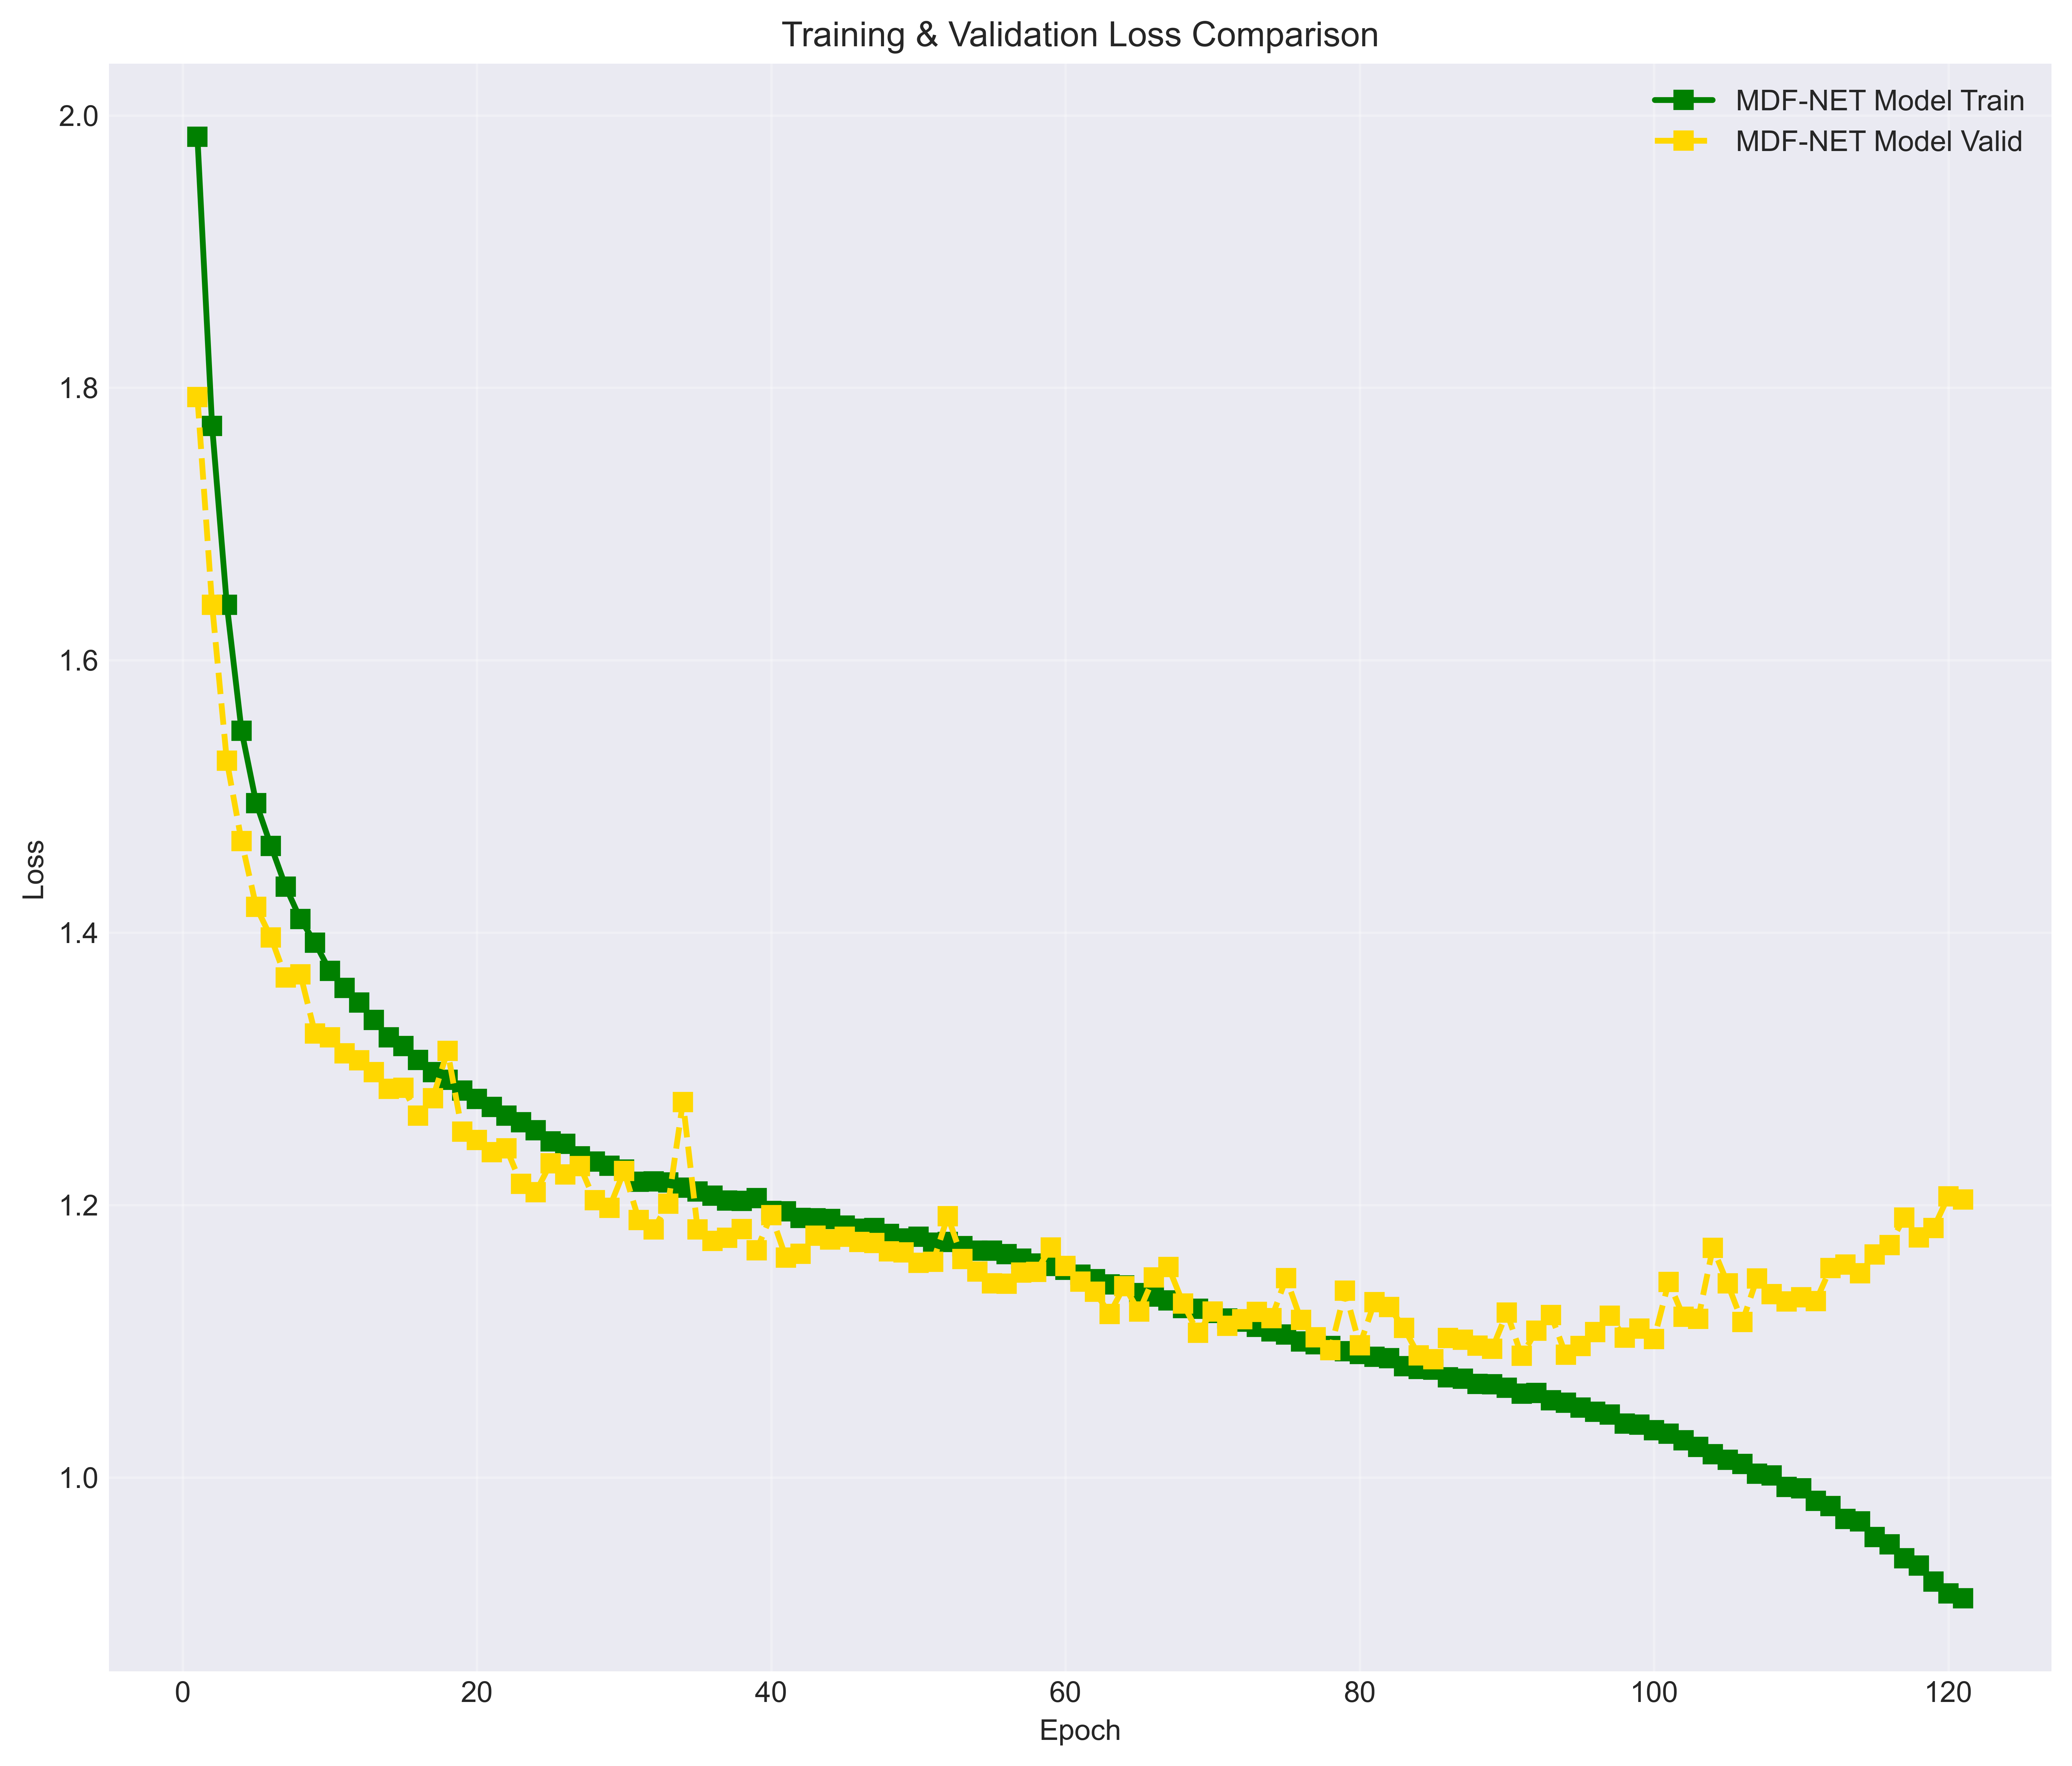

In [ ]:
plt.figure(figsize=(12, 10), dpi=600)
epochs = range(1, len(metrics['train_losses']) + 1)
plt.plot(epochs, metrics['train_losses'], 'r-', label='MDF-NET Model Train', linewidth=2, marker = 's', color = 'green')
plt.plot(epochs, metrics['valid_losses'], 'r--', label='MDF-NET Model Valid', linewidth=2,marker = 's', color = 'gold')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('Training & Validation Loss Comparison')
plt.legend()
plt.grid(True, alpha=0.3)

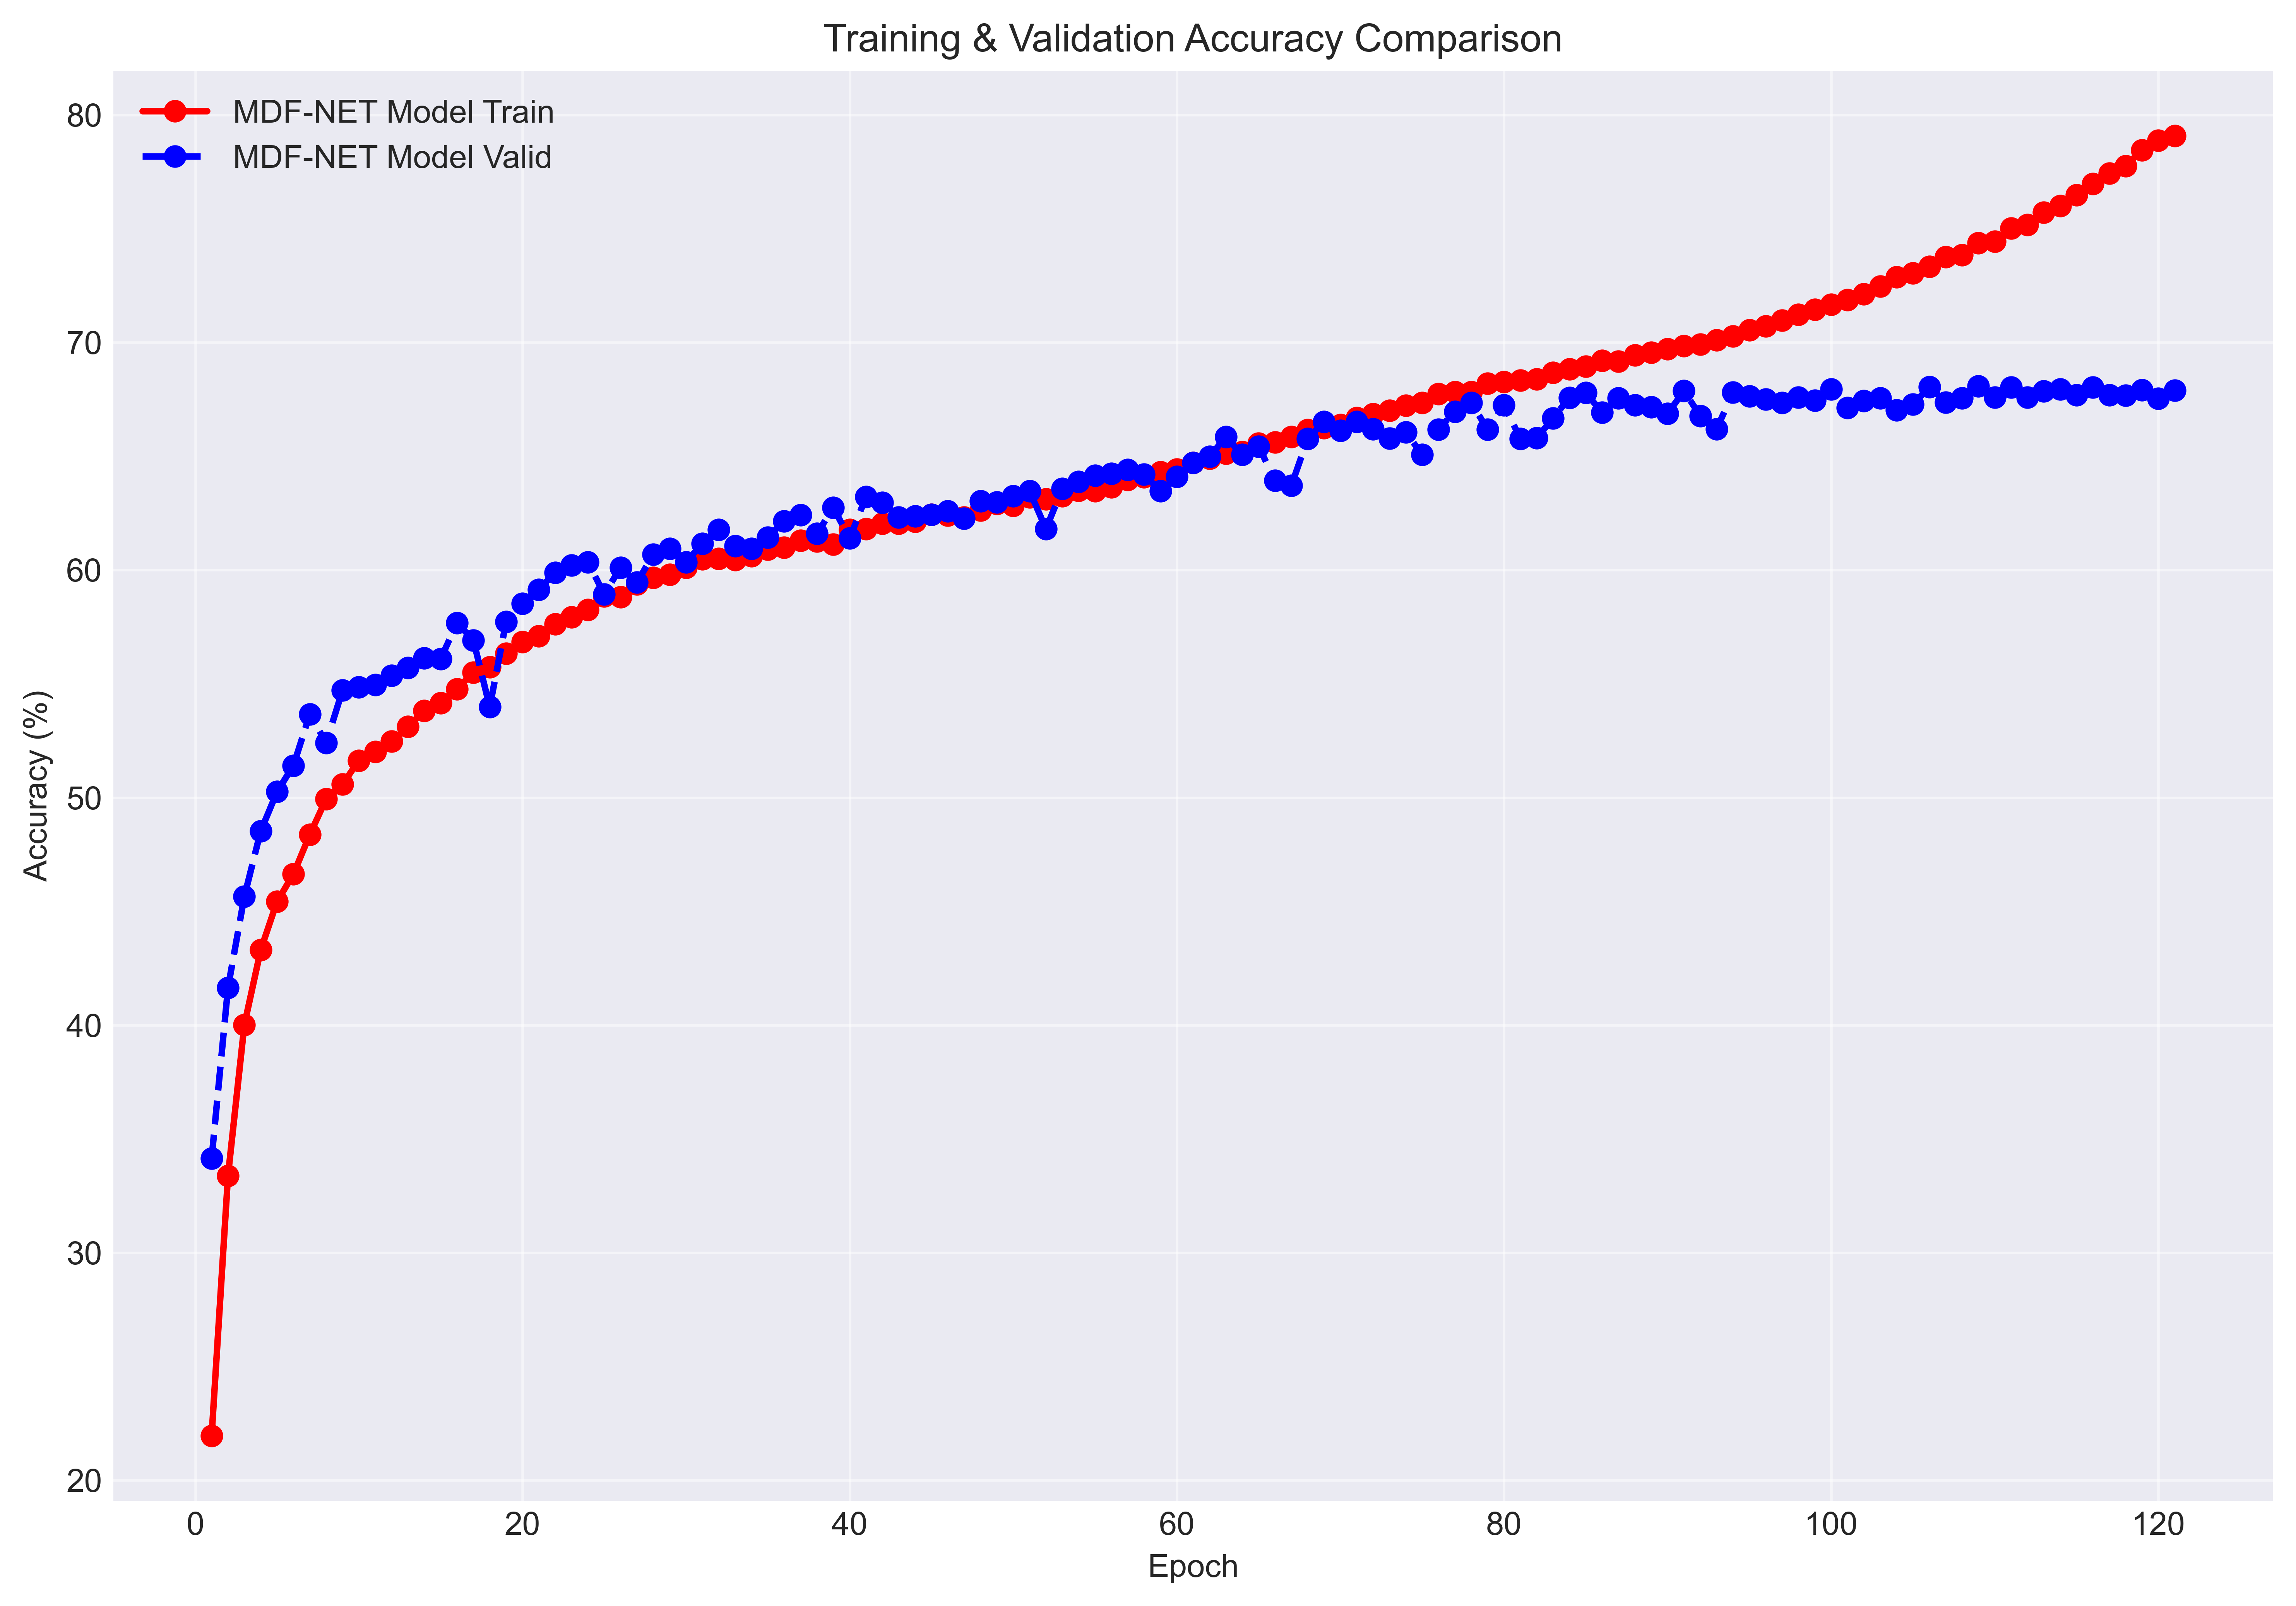

In [ ]:
plt.figure(figsize=(12, 8), dpi=600)
plt.plot(epochs, metrics['train_accuracies'], 'b-', label='MDF-NET Model Train', linewidth=2,color = 'red',marker = 'o')
plt.plot(epochs, metrics['valid_accuracies'], 'b--', label='MDF-NET Model Valid', linewidth=2,color = 'blue', marker = 'o')
plt.xlabel('Epoch')
plt.ylabel('Accuracy (%)')
plt.title('Training & Validation Accuracy Comparison')
plt.legend()
plt.grid(True, alpha=0.5)

✅ Directory 'result_MDF_NET' is ready
✅ Confusion matrix saved to: result_MDF_NET\confusion_matrix_Multi-Domain_Fusion_Model.pdf


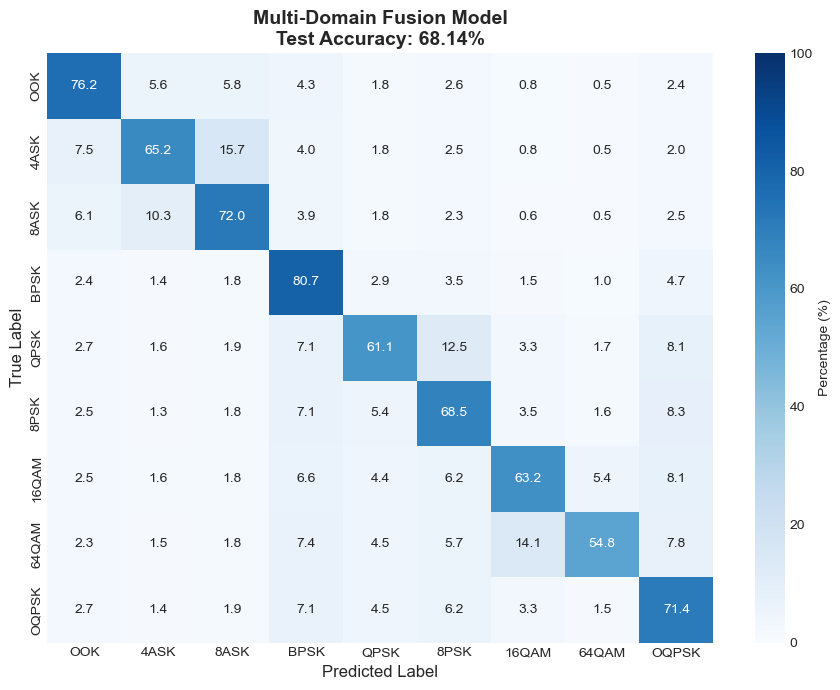

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix
import warnings
import os
from pathlib import Path
warnings.filterwarnings('ignore')

def plot_confusion_matrix_percentage(metrics, model_name, class_names=None, save_dir="result_MDF_NET"):
    """
    Plots a confusion matrix for a single model's test results using percentages.
    
    Args:
        metrics (dict): The metrics dictionary containing test results.
                       Must include 'test_true_labels', 'test_predictions',
                       and 'test_accuracy'.
        model_name (str): The name of the model for the plot title.
        class_names (list, optional): A list of names for the classes.
                                     Defaults to None.
        save_dir (str, optional): Directory to save the plot. 
                                 Defaults to "result_MDF_NET".
    """
    # --- 1. Validate that the necessary data exists ---
    required_keys = ['test_true_labels', 'test_predictions', 'test_accuracy']
    if not all(key in metrics for key in required_keys):
        print("❌ Error: metrics dictionary is missing required test data.")
        print(f"   Expected keys: {required_keys}")
        return
    
    # --- 2. Create the directory if it doesn't exist ---
    Path(save_dir).mkdir(parents=True, exist_ok=True)
    print(f"✅ Directory '{save_dir}' is ready")
    
    # --- 3. Create a single plot ---
    fig, ax = plt.subplots(1, 1, figsize=(9, 7))
    
    # --- 4. Calculate the confusion matrix ---
    cm = confusion_matrix(
        metrics['test_true_labels'],
        metrics['test_predictions']
    )
    
    # --- 5. Convert to percentages (normalize by true label/row) ---
    # Add a small epsilon to avoid division by zero if a class has no samples
    cm_sum = cm.sum(axis=1)[:, np.newaxis] + 1e-9
    cm_pct = cm.astype('float') / cm_sum * 100
    
    # --- 6. Plot the heatmap ---
    sns.heatmap(
        cm_pct,
        annot=True,
        fmt='.1f',
        cmap='Blues',
        xticklabels=class_names,
        yticklabels=class_names,
        ax=ax,
        cbar_kws={'label': 'Percentage (%)'},
        vmin=0,
        vmax=100
    )
    
    ax.set_title(f'{model_name}\nTest Accuracy: {metrics["test_accuracy"]:.2f}%', 
                 fontsize=14, fontweight='bold')
    ax.set_xlabel('Predicted Label', fontsize=12)
    ax.set_ylabel('True Label', fontsize=12)
    
    plt.tight_layout()
    
    # --- 7. Save the figure as PDF with 600 DPI ---
    filename = f"confusion_matrix_{model_name.replace(' ', '_')}.pdf"
    filepath = os.path.join(save_dir, filename)
    
    plt.savefig(
        filepath,
        format='pdf',
        dpi=600,
        bbox_inches='tight',
        pad_inches=0.1
    )
    
    print(f"✅ Confusion matrix saved to: {filepath}")
    
    # --- 8. Display the plot ---
    plt.show()
    
    # --- 9. Close the figure to free memory ---
    plt.close(fig)


# --- USAGE EXAMPLE ---
plot_confusion_matrix_percentage(
    metrics=metrics,
    model_name="Multi-Domain Fusion Model",
    class_names=TARGET_MODULATIONS,
    save_dir="result_MDF_NET"  # Optional: customize the folder name
)

Extracting features from Multi-Domain Fusion model...


Subsampling 2500 data points for t-SNE...
Applying t-SNE... (this may take a moment)


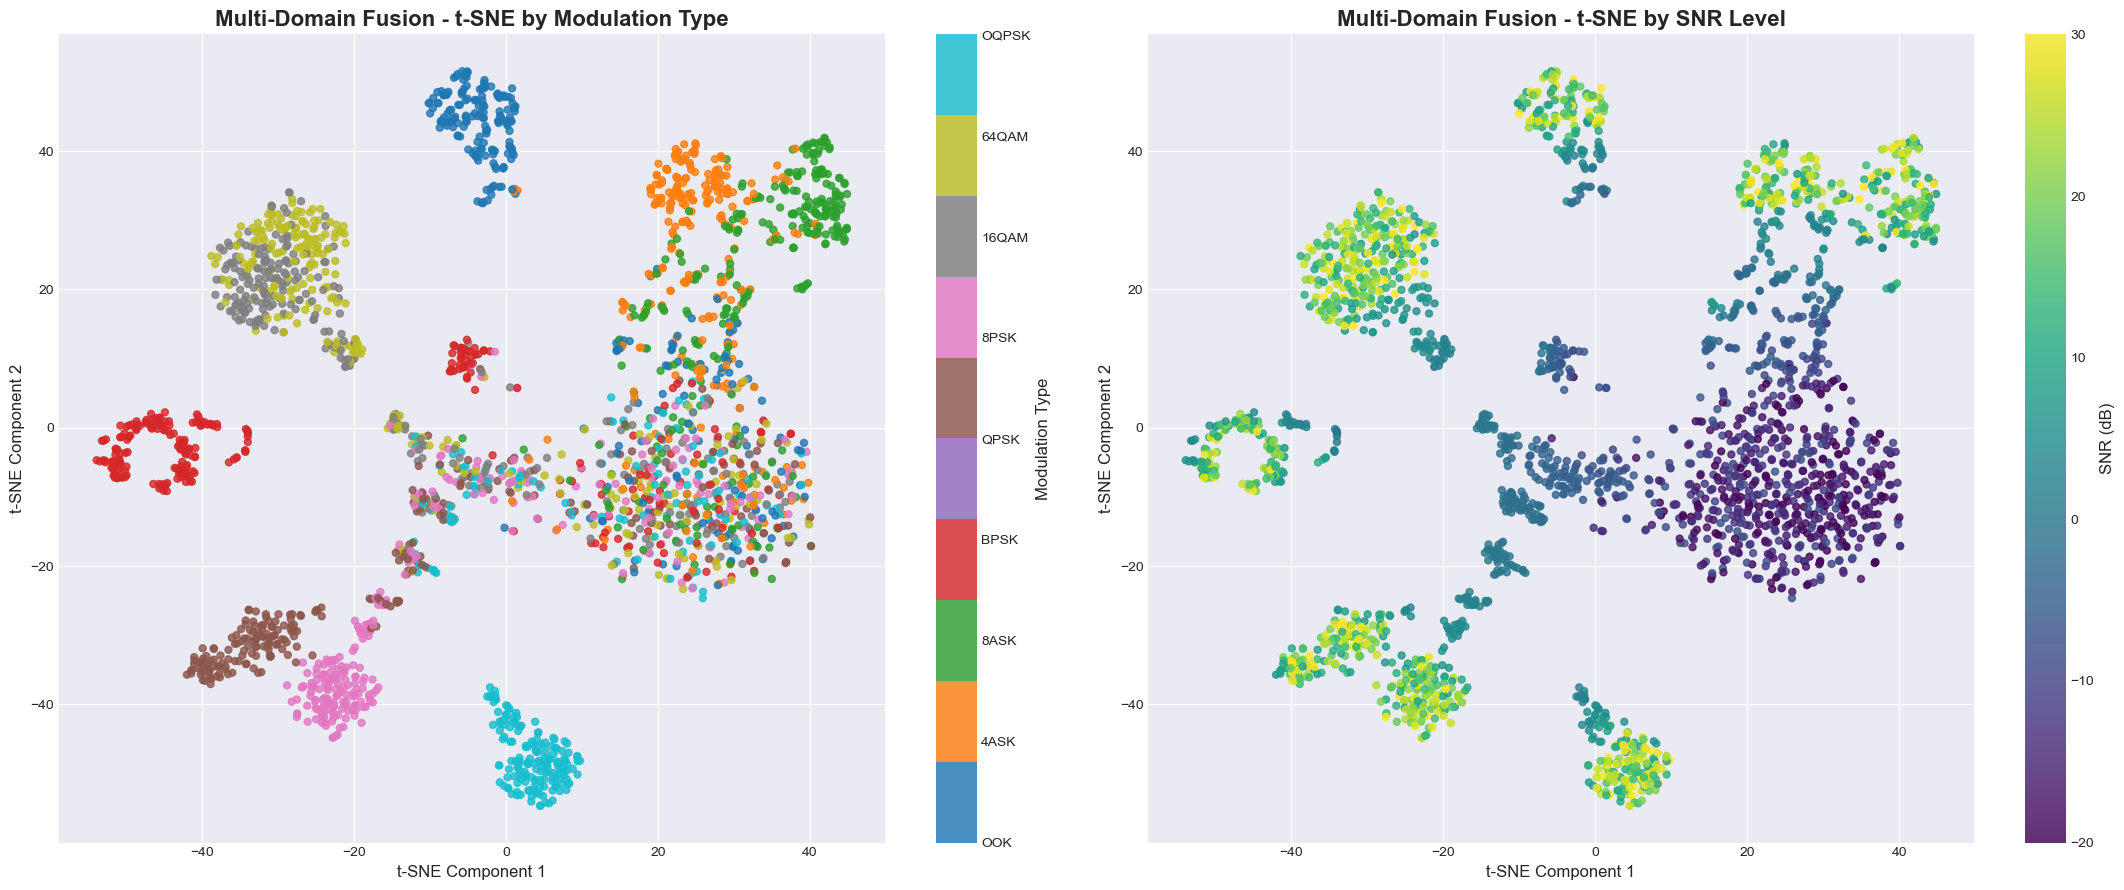

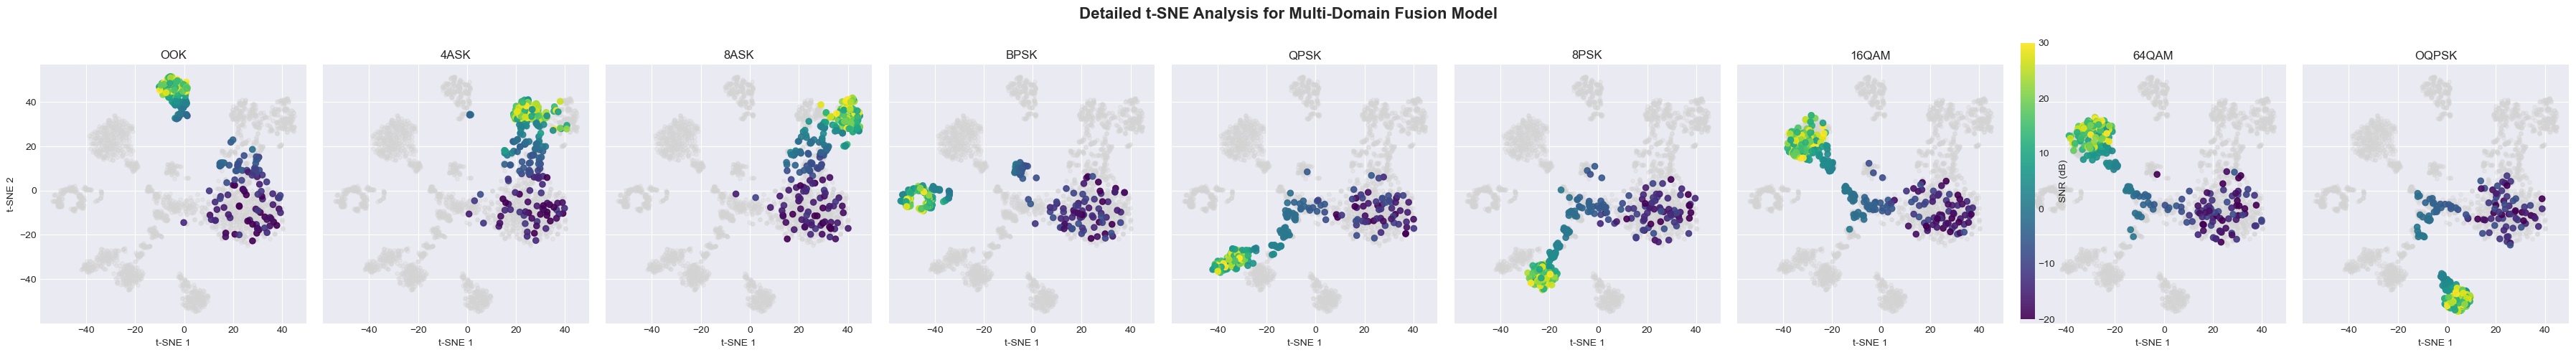

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import torch
from sklearn.manifold import TSNE
from sklearn.preprocessing import StandardScaler
import warnings
warnings.filterwarnings('ignore')

def extract_features_from_model(model, dataloader, device):
    """
    Extract features from the input to the final classifier of the model.
    This version is updated to handle the new 3-input model.

    Args:
        model: PyTorch model with a 'classifier' attribute.
        dataloader: DataLoader containing the data.
        device: Device to run inference on.

    Returns:
        features: Extracted features (numpy array).
        labels: True labels (numpy array).
        snrs: SNR values (numpy array).
    """
    model.eval()
    features_list = []
    labels_list = []
    snrs_list = []

    # This hook captures the INPUT to the specified module.
    # We will hook the classifier to get the final fused feature vector.
    def hook_fn(module, input_tuple, output):
        # The input to a module is a tuple of tensors. We want the first one.
        features_list.append(input_tuple[0].detach().cpu())

    # --- Robust Hook Registration ---
    # This design requires your model to have a final block named 'classifier'.
    if not hasattr(model, 'classifier'):
        raise AttributeError("Model must have a 'classifier' attribute to automatically extract features.")
    
    layer_to_hook = model.classifier
    hook = layer_to_hook.register_forward_hook(hook_fn)

    with torch.no_grad():
        for batch in dataloader:
            # --- ADJUSTMENT: Handle the new 5-item batch from DualStreamRadioMLDataset ---
            if len(batch) == 5:
                amp_inputs, phase_inputs, iq_seq_inputs, labels, snrs = batch
                amp_inputs = amp_inputs.to(device)
                phase_inputs = phase_inputs.to(device)
                iq_seq_inputs = iq_seq_inputs.to(device)
                labels = labels.to(device)
                
                # Forward pass to trigger the hook
                _ = model(amp_inputs, phase_inputs, iq_seq_inputs)
            
            # --- Fallback for old 4-item batch format ---
            elif len(batch) == 4:
                i_inputs, q_inputs, labels, snrs = batch
                i_inputs, q_inputs = i_inputs.to(device), q_inputs.to(device)
                labels = labels.to(device)
                _ = model(i_inputs, q_inputs) # Assumes old model format
            
            else:
                hook.remove() # Clean up hook before raising error
                raise ValueError(f"Unsupported batch size of {len(batch)}. Expected 4 or 5.")

            labels_list.extend(labels.cpu().numpy())
            snrs_list.extend(snrs.cpu().numpy() if hasattr(snrs, 'cpu') else snrs)

    hook.remove()  # IMPORTANT: Always remove the hook after use

    features = torch.cat(features_list, dim=0).numpy()
    
    if len(features.shape) > 2:
        features = features.reshape(features.shape[0], -1)
        
    return features, np.array(labels_list), np.array(snrs_list)

def plot_tsne_visualization(model, model_name, dataloader, device, target_modulations, n_samples=2000):
    """
    Create a t-SNE visualization for a single model's feature representations.
    """
    # --- 1. Extract Features ---
    print(f"Extracting features from {model_name} model...")
    features, labels, snrs = extract_features_from_model(model, dataloader, device)
    
    # --- 2. Subsample for computational efficiency ---
    if len(features) > n_samples:
        print(f"Subsampling {n_samples} data points for t-SNE...")
        indices = np.random.choice(len(features), n_samples, replace=False)
        features = features[indices]
        labels = labels[indices]
        snrs = snrs[indices]

    # --- 3. Apply t-SNE ---
    print("Applying t-SNE... (this may take a moment)")
    tsne = TSNE(n_components=2, random_state=42, perplexity=30, max_iter=1000)
    scaler = StandardScaler()
    features_scaled = scaler.fit_transform(features)
    tsne_results = tsne.fit_transform(features_scaled)

    # --- 4. Create Plots ---
    fig, axes = plt.subplots(1, 2, figsize=(22, 9))
    
    # Plot 1: Color by modulation type
    ax1 = axes[0]
    scatter = ax1.scatter(tsne_results[:, 0], tsne_results[:, 1],
                          c=labels, cmap='tab10', alpha=0.8, s=25)
    ax1.set_title(f'{model_name} - t-SNE by Modulation Type', fontsize=16, fontweight='bold')
    ax1.set_xlabel('t-SNE Component 1', fontsize=12)
    ax1.set_ylabel('t-SNE Component 2', fontsize=12)
    cbar = fig.colorbar(scatter, ax=ax1, ticks=range(len(target_modulations)))
    cbar.set_ticklabels(target_modulations)
    cbar.set_label('Modulation Type', fontsize=12)
    
    # Plot 2: Color by SNR level
    ax2 = axes[1]
    scatter_snr = ax2.scatter(tsne_results[:, 0], tsne_results[:, 1],
                              c=snrs, cmap='viridis', alpha=0.8, s=25)
    ax2.set_title(f'{model_name} - t-SNE by SNR Level', fontsize=16, fontweight='bold')
    ax2.set_xlabel('t-SNE Component 1', fontsize=12)
    ax2.set_ylabel('t-SNE Component 2', fontsize=12)
    cbar_snr = fig.colorbar(scatter_snr, ax=ax2)
    cbar_snr.set_label('SNR (dB)', fontsize=12)
    
    plt.tight_layout()
    plt.savefig(f'tsne_{model_name}_visualization.png', dpi=300, bbox_inches='tight')
    plt.show()

    # --- 5. Create Detailed Analysis Plot ---
    create_detailed_tsne_analysis(tsne_results, labels, snrs, target_modulations, model_name)

def create_detailed_tsne_analysis(tsne_results, labels, snrs, target_modulations, model_name):
    """
    Create detailed t-SNE analysis with per-modulation separation for a single model.
    """
    num_modulations = len(target_modulations)
    fig, axes = plt.subplots(1, num_modulations, figsize=(4 * num_modulations, 5), sharex=True, sharey=True)
    fig.suptitle(f'Detailed t-SNE Analysis for {model_name} Model', fontsize=16, fontweight='bold')

    for mod_idx, modulation in enumerate(target_modulations):
        ax = axes[mod_idx]
        
        # Highlight current modulation
        current_mask = (labels == mod_idx)
        other_mask = (labels != mod_idx)
        
        # Plot other modulations in gray
        ax.scatter(tsne_results[other_mask, 0], tsne_results[other_mask, 1],
                   c='lightgray', alpha=0.3, s=15, label='Other')
        
        # Plot current modulation colored by SNR
        if np.sum(current_mask) > 0:
            scatter = ax.scatter(tsne_results[current_mask, 0], tsne_results[current_mask, 1],
                                 c=snrs[current_mask], cmap='viridis', alpha=0.9, s=35,
                                 label=modulation, vmin=snrs.min(), vmax=snrs.max())
        
        ax.set_title(f'{modulation}', fontsize=12)
        ax.set_xlabel('t-SNE 1')

    # Add a single colorbar for SNR
    fig.colorbar(scatter, ax=axes.ravel().tolist(), label='SNR (dB)', pad=0.01)
    axes[0].set_ylabel('t-SNE 2')
    
    plt.tight_layout(rect=[0, 0, 1, 0.96]) # Adjust for suptitle
    plt.savefig(f'tsne_{model_name}_detailed.png', dpi=600, bbox_inches='tight')
    plt.show()

# --- USAGE EXAMPLE ---
#
# model_new = ... # Your new, trained MultiDomainFusionModel
# model_new.load_state_dict(best_model_state) # Load best weights
#
# test_loader = ... # Your test dataloader from DualStreamRadioMLDataset
# device = ...      # Your device
# TARGET_MODULATIONS = ... # Your list of modulation names
# 
plot_tsne_visualization(
    model=model_new,
    model_name='Multi-Domain Fusion', # A descriptive name for your model
    dataloader=test_loader,
    device=device,
    target_modulations=TARGET_MODULATIONS,
    n_samples=2500
)


Extracting features from Multi-Domain Fusion model...


Subsampling 2500 data points for t-SNE...
Applying t-SNE... (this may take a moment)


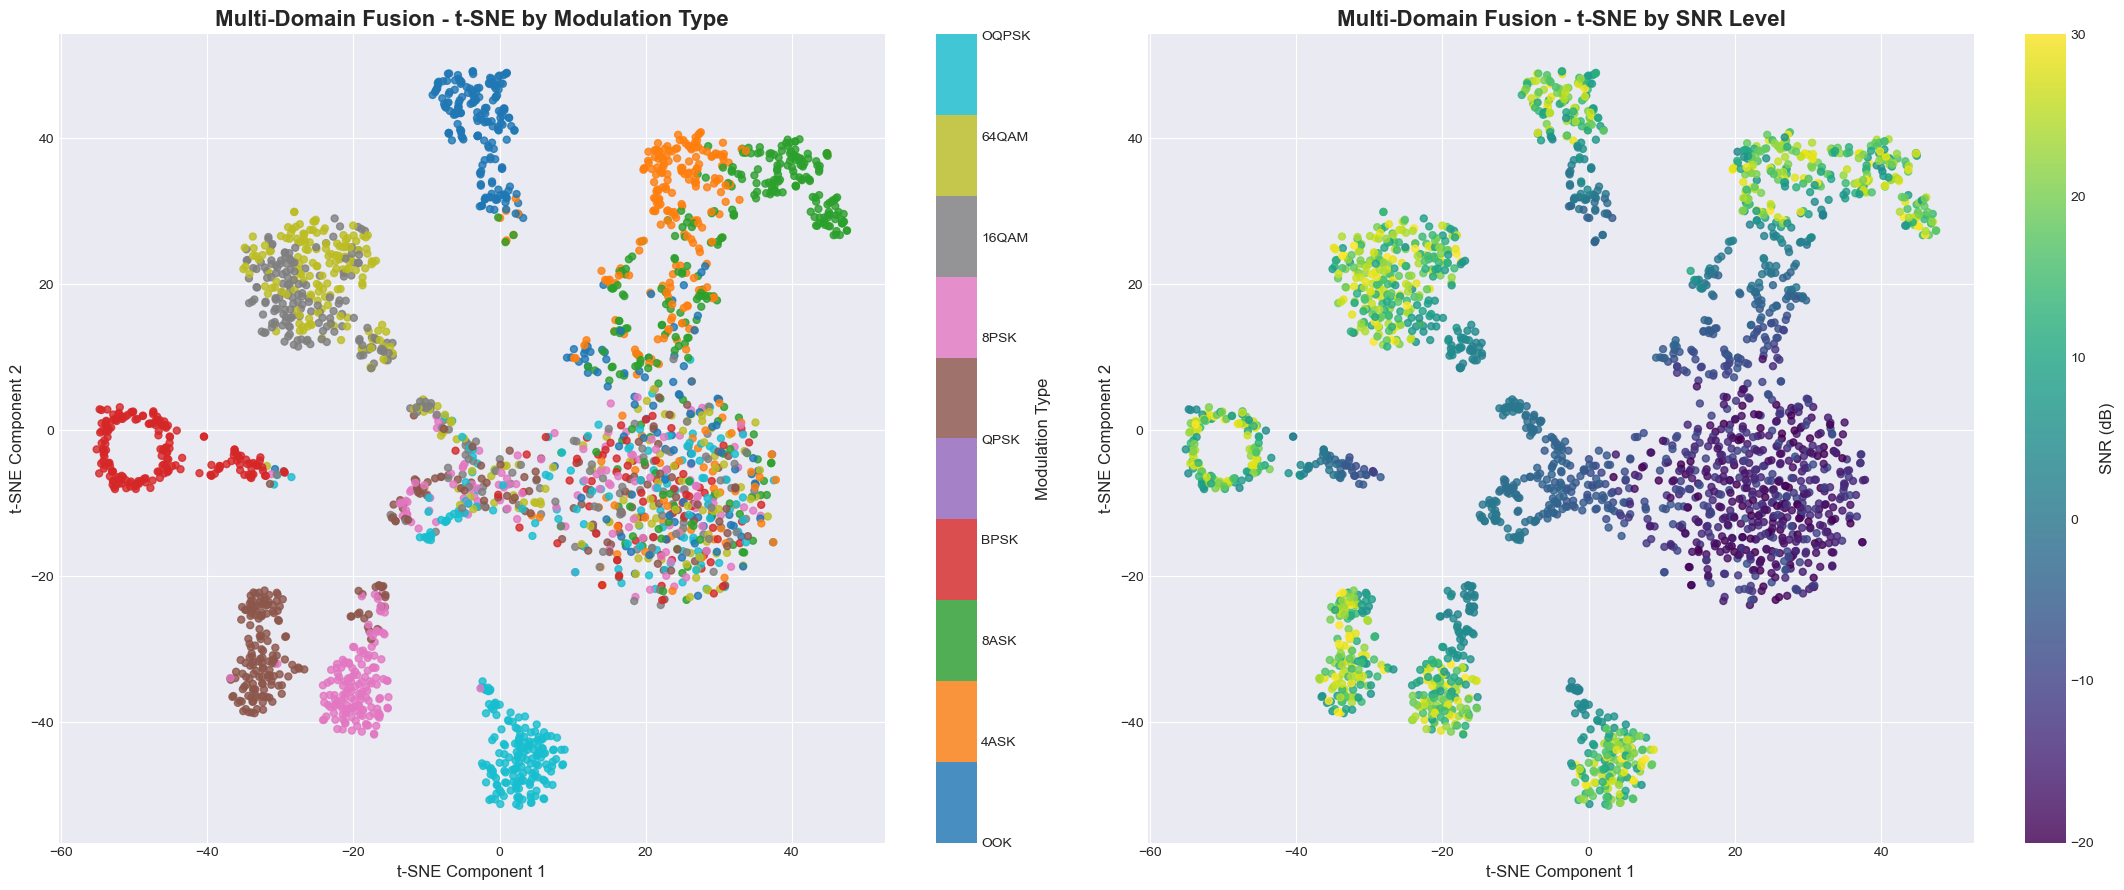

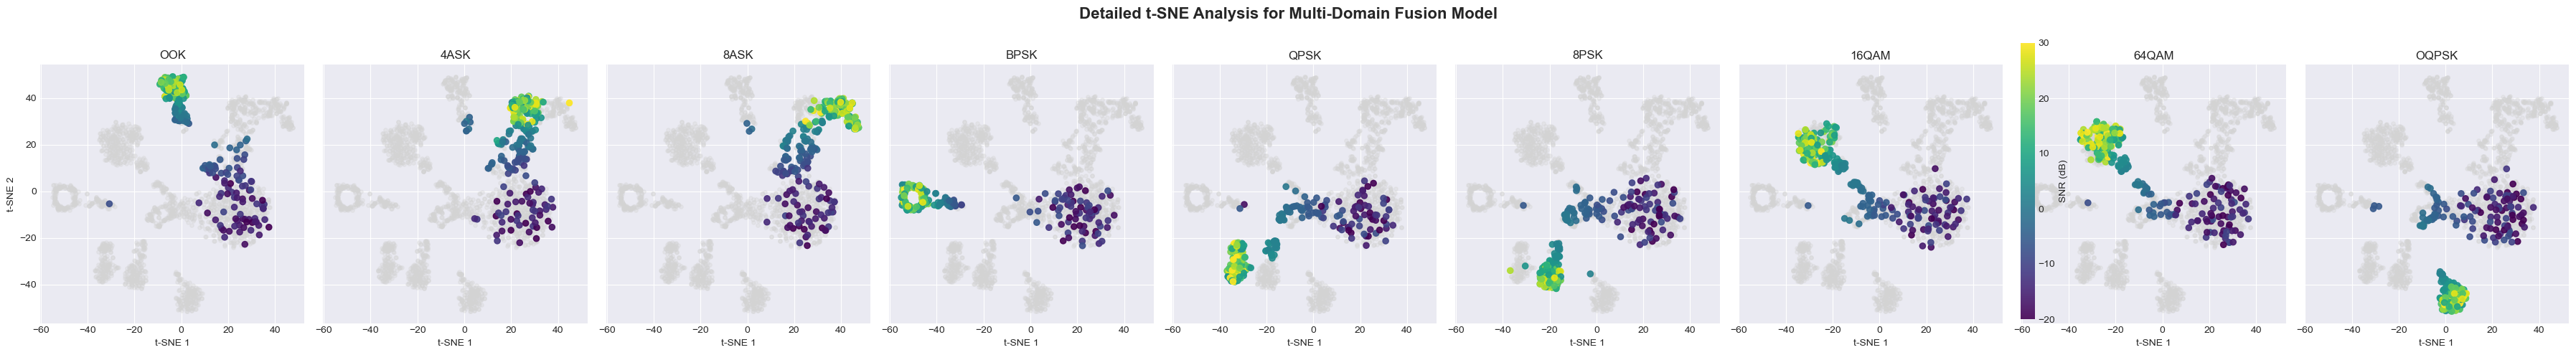

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import torch
from sklearn.manifold import TSNE
from sklearn.preprocessing import StandardScaler
import warnings
warnings.filterwarnings('ignore')

def extract_features_from_model(model, dataloader, device):
    """
    Extract features from the input to the final classifier of the model.
    This version is updated to handle the new 3-input model.

    Args:
        model: PyTorch model with a 'classifier' attribute.
        dataloader: DataLoader containing the data.
        device: Device to run inference on.

    Returns:
        features: Extracted features (numpy array).
        labels: True labels (numpy array).
        snrs: SNR values (numpy array).
    """
    model.eval()
    features_list = []
    labels_list = []
    snrs_list = []

    # This hook captures the INPUT to the specified module.
    # We will hook the classifier to get the final fused feature vector.
    def hook_fn(module, input_tuple, output):
        # The input to a module is a tuple of tensors. We want the first one.
        features_list.append(input_tuple[0].detach().cpu())

    # --- Robust Hook Registration ---
    # This design requires your model to have a final block named 'classifier'.
    if not hasattr(model, 'classifier'):
        raise AttributeError("Model must have a 'classifier' attribute to automatically extract features.")
    
    layer_to_hook = model.classifier
    hook = layer_to_hook.register_forward_hook(hook_fn)

    with torch.no_grad():
        for batch in dataloader:
            # --- ADJUSTMENT: Handle the new 5-item batch from DualStreamRadioMLDataset ---
            if len(batch) == 5:
                amp_inputs, phase_inputs, iq_seq_inputs, labels, snrs = batch
                amp_inputs = amp_inputs.to(device)
                phase_inputs = phase_inputs.to(device)
                iq_seq_inputs = iq_seq_inputs.to(device)
                labels = labels.to(device)
                
                # Forward pass to trigger the hook
                _ = model(amp_inputs, phase_inputs, iq_seq_inputs)
            
            # --- Fallback for old 4-item batch format ---
            elif len(batch) == 4:
                i_inputs, q_inputs, labels, snrs = batch
                i_inputs, q_inputs = i_inputs.to(device), q_inputs.to(device)
                labels = labels.to(device)
                _ = model(i_inputs, q_inputs) # Assumes old model format
            
            else:
                hook.remove() # Clean up hook before raising error
                raise ValueError(f"Unsupported batch size of {len(batch)}. Expected 4 or 5.")

            labels_list.extend(labels.cpu().numpy())
            snrs_list.extend(snrs.cpu().numpy() if hasattr(snrs, 'cpu') else snrs)

    hook.remove()  # IMPORTANT: Always remove the hook after use

    features = torch.cat(features_list, dim=0).numpy()
    
    if len(features.shape) > 2:
        features = features.reshape(features.shape[0], -1)
        
    return features, np.array(labels_list), np.array(snrs_list)

def plot_tsne_visualization(model, model_name, dataloader, device, target_modulations, n_samples=2000):
    """
    Create a t-SNE visualization for a single model's feature representations.
    """
    # --- 1. Extract Features ---
    print(f"Extracting features from {model_name} model...")
    features, labels, snrs = extract_features_from_model(model, dataloader, device)
    
    # --- 2. Subsample for computational efficiency ---
    if len(features) > n_samples:
        print(f"Subsampling {n_samples} data points for t-SNE...")
        indices = np.random.choice(len(features), n_samples, replace=False)
        features = features[indices]
        labels = labels[indices]
        snrs = snrs[indices]

    # --- 3. Apply t-SNE ---
    print("Applying t-SNE... (this may take a moment)")
    tsne = TSNE(n_components=2, random_state=42, perplexity=30, max_iter=1000)
    scaler = StandardScaler()
    features_scaled = scaler.fit_transform(features)
    tsne_results = tsne.fit_transform(features_scaled)

    # --- 4. Create Plots ---
    fig, axes = plt.subplots(1, 2, figsize=(22, 9))
    
    # Plot 1: Color by modulation type
    ax1 = axes[0]
    scatter = ax1.scatter(tsne_results[:, 0], tsne_results[:, 1],
                          c=labels, cmap='tab10', alpha=0.8, s=25)
    ax1.set_title(f'{model_name} - t-SNE by Modulation Type', fontsize=16, fontweight='bold')
    ax1.set_xlabel('t-SNE Component 1', fontsize=12)
    ax1.set_ylabel('t-SNE Component 2', fontsize=12)
    cbar = fig.colorbar(scatter, ax=ax1, ticks=range(len(target_modulations)))
    cbar.set_ticklabels(target_modulations)
    cbar.set_label('Modulation Type', fontsize=12)
    
    # Plot 2: Color by SNR level
    ax2 = axes[1]
    scatter_snr = ax2.scatter(tsne_results[:, 0], tsne_results[:, 1],
                              c=snrs, cmap='viridis', alpha=0.8, s=25)
    ax2.set_title(f'{model_name} - t-SNE by SNR Level', fontsize=16, fontweight='bold')
    ax2.set_xlabel('t-SNE Component 1', fontsize=12)
    ax2.set_ylabel('t-SNE Component 2', fontsize=12)
    cbar_snr = fig.colorbar(scatter_snr, ax=ax2)
    cbar_snr.set_label('SNR (dB)', fontsize=12)
    
    plt.tight_layout()
    plt.savefig(f'tsne_{model_name}_visualization.png', dpi=300, bbox_inches='tight')
    plt.show()

    # --- 5. Create Detailed Analysis Plot ---
    create_detailed_tsne_analysis(tsne_results, labels, snrs, target_modulations, model_name)

def create_detailed_tsne_analysis(tsne_results, labels, snrs, target_modulations, model_name):
    """
    Create detailed t-SNE analysis with per-modulation separation for a single model.
    """
    num_modulations = len(target_modulations)
    fig, axes = plt.subplots(1, num_modulations, figsize=(4 * num_modulations, 5), sharex=True, sharey=True)
    fig.suptitle(f'Detailed t-SNE Analysis for {model_name} Model', fontsize=16, fontweight='bold')

    for mod_idx, modulation in enumerate(target_modulations):
        ax = axes[mod_idx]
        
        # Highlight current modulation
        current_mask = (labels == mod_idx)
        other_mask = (labels != mod_idx)
        
        # Plot other modulations in gray
        ax.scatter(tsne_results[other_mask, 0], tsne_results[other_mask, 1],
                   c='lightgray', alpha=0.3, s=15, label='Other')
        
        # Plot current modulation colored by SNR
        if np.sum(current_mask) > 0:
            scatter = ax.scatter(tsne_results[current_mask, 0], tsne_results[current_mask, 1],
                                 c=snrs[current_mask], cmap='viridis', alpha=0.9, s=35,
                                 label=modulation, vmin=snrs.min(), vmax=snrs.max())
        
        ax.set_title(f'{modulation}', fontsize=12)
        ax.set_xlabel('t-SNE 1')

    # Add a single colorbar for SNR
    fig.colorbar(scatter, ax=axes.ravel().tolist(), label='SNR (dB)', pad=0.01)
    axes[0].set_ylabel('t-SNE 2')
    
    plt.tight_layout(rect=[0, 0, 1, 0.96]) # Adjust for suptitle
    plt.savefig(f'tsne_{model_name}_detailed.png', dpi=300, bbox_inches='tight')
    plt.show()

# --- USAGE EXAMPLE ---
#
# model_new = ... # Your new, trained MultiDomainFusionModel
# model_new.load_state_dict(best_model_state) # Load best weights
#
# test_loader = ... # Your test dataloader from DualStreamRadioMLDataset
# device = ...      # Your device
# TARGET_MODULATIONS = ... # Your list of modulation names
# 
plot_tsne_visualization(
    model=model_new,
    model_name='Multi-Domain Fusion', # A descriptive name for your model
    dataloader=valid_loader,
    device=device,
    target_modulations=TARGET_MODULATIONS,
    n_samples=2500
)


Gathering predictions from 'Multi-Domain Fusion' model...


Evaluating Model: 100%|██████████| 281/281 [00:38<00:00,  7.31it/s]


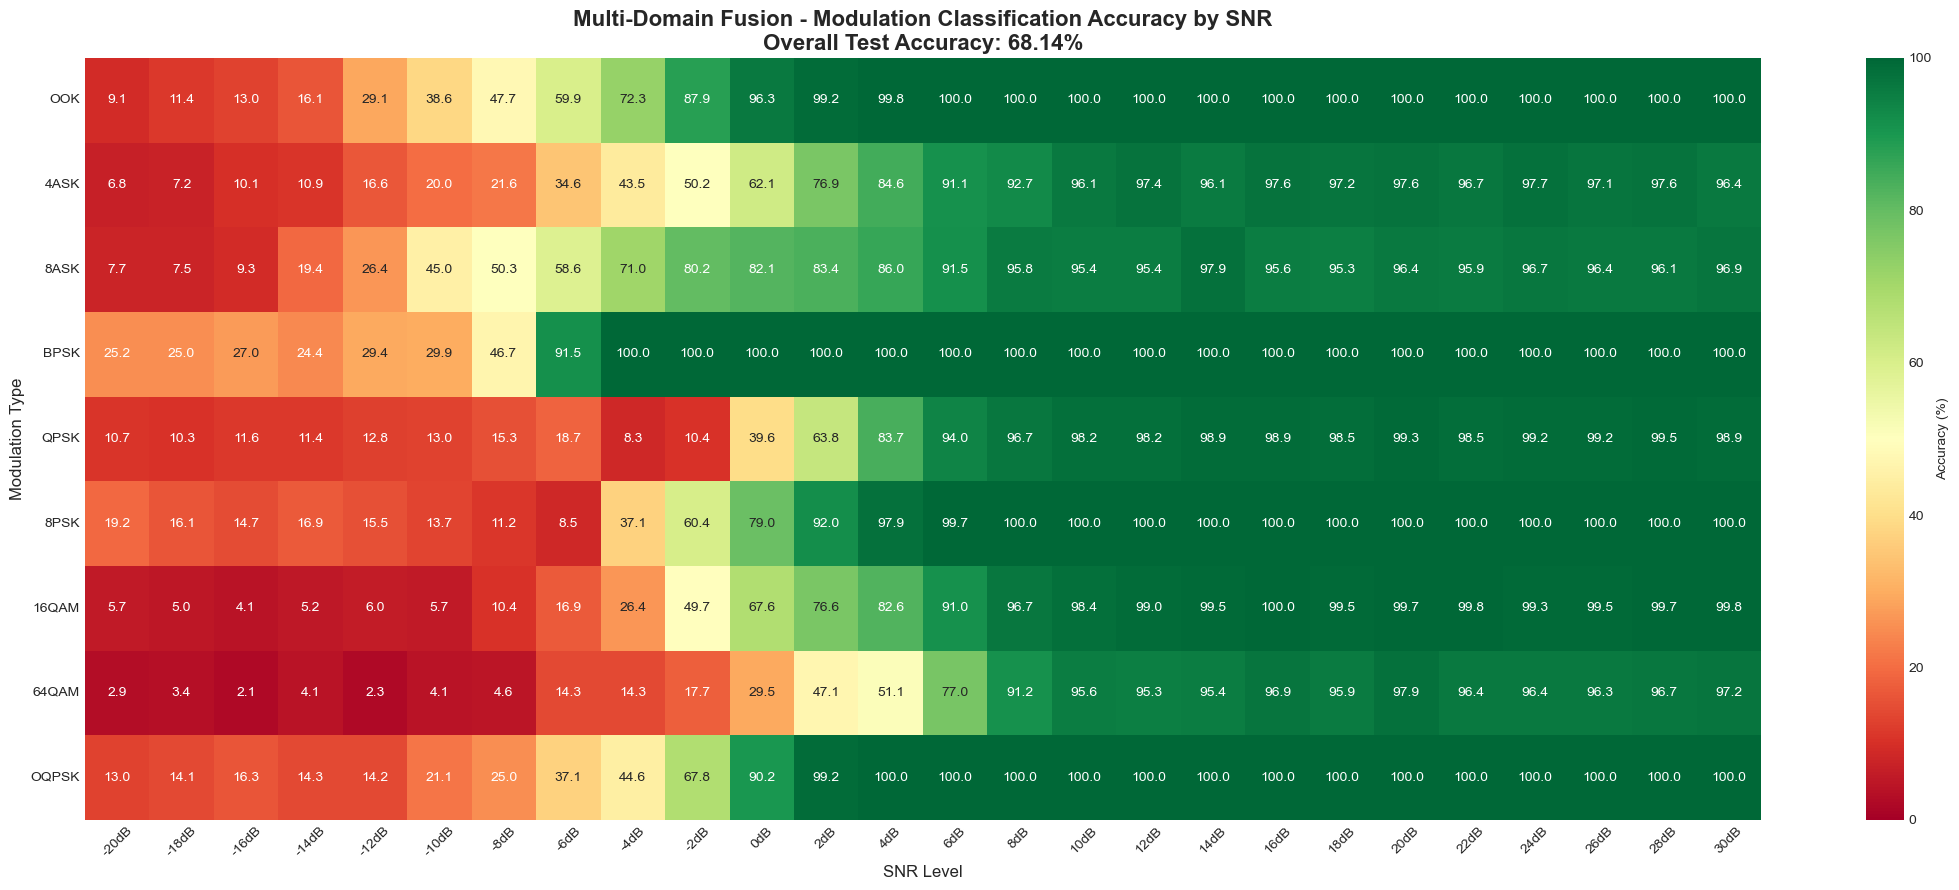

In [ ]:
def plot_snr_accuracy_heatmap(model, model_name, dataloader, device, target_modulations):
    """
    Plots a detailed accuracy heatmap for a single model across all modulations and SNR levels.
    This version is adapted for the Multi-Domain Fusion model and its specific data loader.

    Args:
        model: The trained PyTorch model to evaluate.
        model_name (str): A descriptive name for the model for the plot title.
        dataloader: The DataLoader containing the test data.
        device: The device to run inference on.
        target_modulations (list): A list of the modulation class names.
    """
    model.eval()
    all_predictions = []
    all_true_labels = []
    all_snrs = []

    print(f"Gathering predictions from '{model_name}' model...")
    with torch.no_grad():
        # Iterate through the dataloader with a progress bar
        for batch in tqdm(dataloader, desc="Evaluating Model"):
            # --- ADJUSTMENT: Explicitly handle the 5-item batch ---
            amp_inputs, phase_inputs, iq_seq_inputs, labels, snrs = batch
            
            amp_inputs = amp_inputs.to(device)
            phase_inputs = phase_inputs.to(device)
            iq_seq_inputs = iq_seq_inputs.to(device)
            labels = labels.to(device)
            
            # --- ADJUSTMENT: Call the model with its three required inputs ---
            outputs = model(amp_inputs, phase_inputs, iq_seq_inputs)
            
            _, predicted = torch.max(outputs, 1)
            
            all_predictions.extend(predicted.cpu().numpy())
            all_true_labels.extend(labels.cpu().numpy())
            all_snrs.extend(snrs.cpu().numpy())

    # --- Create a DataFrame for easy analysis ---
    results_df = pd.DataFrame({
        'true_label': all_true_labels,
        'predicted_label': all_predictions,
        'snr': all_snrs
    })
    
    # --- Calculate the accuracy matrix ---
    unique_snrs = sorted(results_df['snr'].unique())
    accuracy_matrix = np.zeros((len(target_modulations), len(unique_snrs)))

    for i, mod_name in enumerate(target_modulations):
        # The label index corresponds to the modulation index
        mod_label_index = i 
        for j, snr in enumerate(unique_snrs):
            # Filter for the specific modulation and SNR
            subset = results_df[(results_df['true_label'] == mod_label_index) & (results_df['snr'] == snr)]
            if len(subset) > 0:
                # Calculate accuracy for this specific slice of data
                accuracy = (subset['true_label'] == subset['predicted_label']).mean()
                accuracy_matrix[i, j] = accuracy * 100
            else:
                accuracy_matrix[i, j] = 0 # No samples for this combination

    # --- Plot the heatmap ---
    fig, ax = plt.subplots(1, 1, figsize=(22, 9))
    
    overall_accuracy = (results_df['true_label'] == results_df['predicted_label']).mean() * 100
    
    sns.heatmap(
        accuracy_matrix,
        xticklabels=[f'{int(snr)}dB' for snr in unique_snrs],
        yticklabels=target_modulations,
        annot=True,
        fmt='.1f',
        cmap='RdYlGn',
        vmin=0,
        vmax=100,
        cbar_kws={'label': 'Accuracy (%)'},
        ax=ax
    )
    
    ax.set_title(
        f'{model_name} - Modulation Classification Accuracy by SNR\n'
        f'Overall Test Accuracy: {overall_accuracy:.2f}%',
        fontsize=16, fontweight='bold'
    )
    ax.set_xlabel('SNR Level', fontsize=12)
    ax.set_ylabel('Modulation Type', fontsize=12)
    ax.tick_params(axis='x', rotation=45)
    ax.tick_params(axis='y', rotation=0)
    
    plt.tight_layout()
    plt.savefig(f'snr_accuracy_heatmap_{model_name.replace(" ", "_")}.png', dpi=300, bbox_inches='tight')
    plt.show()

# --- USAGE EXAMPLE ---
#
# # Assume you have:
# # model_new: Your trained MultiDomainFusionModel
# # test_loader: The DataLoader for your test set
# # device: Your target device
# # TARGET_MODULATIONS: List of class names
#
plot_snr_accuracy_heatmap(
    model=model_new,
    model_name='Multi-Domain Fusion',
    dataloader=test_loader,
    device=device,
    target_modulations=TARGET_MODULATIONS
)


In [ ]:
import torch
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix
from pathlib import Path
import os

def plot_confusion_matrices_for_snrs(model, model_name, dataloader, device, target_modulations, snrs_to_plot, 
                                     save_pdf=True, output_dir="result_MDF_NET", dpi=600):
    """
    Generates and plots confusion matrices for a model at specific SNR levels.
    (Version 4: Handles Multi-Domain Fusion Model with amp, phase, and iq_seq inputs)
    
    Parameters:
    -----------
    model : torch.nn.Module
        The model to evaluate
    model_name : str
        Name of the model for title and filename
    dataloader : torch.utils.data.DataLoader
        DataLoader containing test data
    device : torch.device
        Device to run inference on
    target_modulations : list
        List of modulation class names
    snrs_to_plot : list
        List of SNR values to plot (should be 3 values for 3x1 layout)
    save_pdf : bool, default=True
        Whether to save the plot as PDF
    output_dir : str, default="result_MDF_NET"
        Directory to save the PDF file
    dpi : int, default=600
        Resolution in dots per inch for the saved PDF
    """
    # Handle "standard" model name conversion to "Serial"
    if model_name.lower() == "standard":
        model_name = "Serial"
    
    # --- Create output directory if it doesn't exist ---
    if save_pdf:
        Path(output_dir).mkdir(parents=True, exist_ok=True)
        print(f"✅ Directory '{output_dir}' is ready")
    
    model.eval()
    all_predictions = []
    all_true_labels = []
    all_snrs = []
    
    # --- 1. Collect Predictions from Dataloader ---
    with torch.no_grad():
        for batch in dataloader:
            # --- MODIFIED TO HANDLE MULTI-DOMAIN FUSION MODEL ---
            # Check if batch has 5 items (amp, phase, iq_seq, labels, snrs)
            if len(batch) == 5:
                amp_inputs, phase_inputs, iq_seq_inputs, labels, snrs = batch
                amp_inputs = amp_inputs.to(device)
                phase_inputs = phase_inputs.to(device)
                iq_seq_inputs = iq_seq_inputs.to(device)
                labels = labels.to(device)
                # Pass all three inputs to the Multi-Domain Fusion Model
                outputs = model(amp_inputs, phase_inputs, iq_seq_inputs)
            
            # Handle dual input models (i_inputs, q_inputs, labels, snrs)
            elif len(batch) == 4:
                i_inputs, q_inputs, labels, snrs = batch
                i_inputs, q_inputs = i_inputs.to(device), q_inputs.to(device)
                labels = labels.to(device)
                outputs = model(i_inputs, q_inputs)
            
            # Handle single input models (inputs, labels, snrs)
            elif len(batch) == 3:
                inputs, labels, snrs = batch
                inputs = inputs.to(device)
                labels = labels.to(device)
                outputs = model(inputs)
            
            # Fallback for other formats
            else:
                inputs, labels = batch
                inputs = inputs.to(device)
                labels = labels.to(device)
                snrs = torch.zeros(len(labels))
                outputs = model(inputs)
                print("⚠️ Warning: Assuming single input and no SNR info.")
            
            _, predicted = torch.max(outputs, 1)
            all_predictions.extend(predicted.cpu().numpy())
            all_true_labels.extend(labels.cpu().numpy())
            all_snrs.extend(snrs.numpy() if hasattr(snrs, 'numpy') else snrs)
    
    # --- 2. Create a DataFrame for Easy Filtering ---
    predictions_df = pd.DataFrame({
        'true_label': all_true_labels,
        'predicted_label': all_predictions,
        'snr': all_snrs
    })
    
    # --- 3. Generate and Plot Confusion Matrices in 3x1 Layout ---
    num_snrs = len(snrs_to_plot)
    
    # Create figure with 3 rows and 1 column
    fig, axes = plt.subplots(1, num_snrs, figsize=(8 * num_snrs, 6.5))
    
    # Handle case where only 1 SNR is provided
    if num_snrs == 1:
        axes = [axes]
    
    fig.suptitle(f'Confusion Matrices for {model_name} Model', fontsize=18, fontweight='bold', y=0.995)
                    
    for i, snr in enumerate(snrs_to_plot):
        ax = axes[i]
        subset_df = predictions_df[predictions_df['snr'] == snr]
        
        if subset_df.empty:
            print(f"⚠️ No data found for SNR = {snr} dB. Skipping plot.")
            ax.text(0.5, 0.5, f'No data for SNR={snr}dB', ha='center', va='center')
            ax.set_title(f'({chr(97 + i)}) SNR = {snr} dB', fontsize=14)
            continue
        
        cm = confusion_matrix(subset_df['true_label'], subset_df['predicted_label'])
        cm_normalized = cm.astype('float') / cm.sum(axis=1)[:, np.newaxis]
        cm_normalized = np.nan_to_num(cm_normalized)
        
        sns.heatmap(cm_normalized, annot=True, fmt='.2f', cmap='Blues',
                    xticklabels=target_modulations, yticklabels=target_modulations, ax=ax,
                    cbar=True, cbar_kws={'label': 'Normalized Count'})
        
        ax.set_title(f'({chr(97 + i)}) SNR = {snr} dB', fontsize=14, pad=10)
        ax.set_xlabel('Predicted Label', fontsize=12)
        ax.set_ylabel('True Label', fontsize=12)
        ax.tick_params(axis='x', rotation=45, labelsize=10)
        ax.tick_params(axis='y', rotation=0, labelsize=10)
    
    plt.tight_layout()
    
    # --- 4. Save as PDF with high DPI in the specified directory ---
    if save_pdf:
        filename = f'confusion_matrices_{model_name.lower().replace(" ", "_")}.pdf'
        output_path = os.path.join(output_dir, filename)
        
        plt.savefig(output_path, format='pdf', dpi=dpi, bbox_inches='tight')
        print(f"✅ Confusion matrices saved to '{output_path}' at {dpi} DPI")
    
    plt.show()
    
    # Close figure to free memory
    plt.close(fig)


✅ Directory 'result_MDF_NET' is ready
✅ Confusion matrices saved to 'result_MDF_NET\confusion_matrices_multi-domain_fusion_model.pdf' at 600 DPI


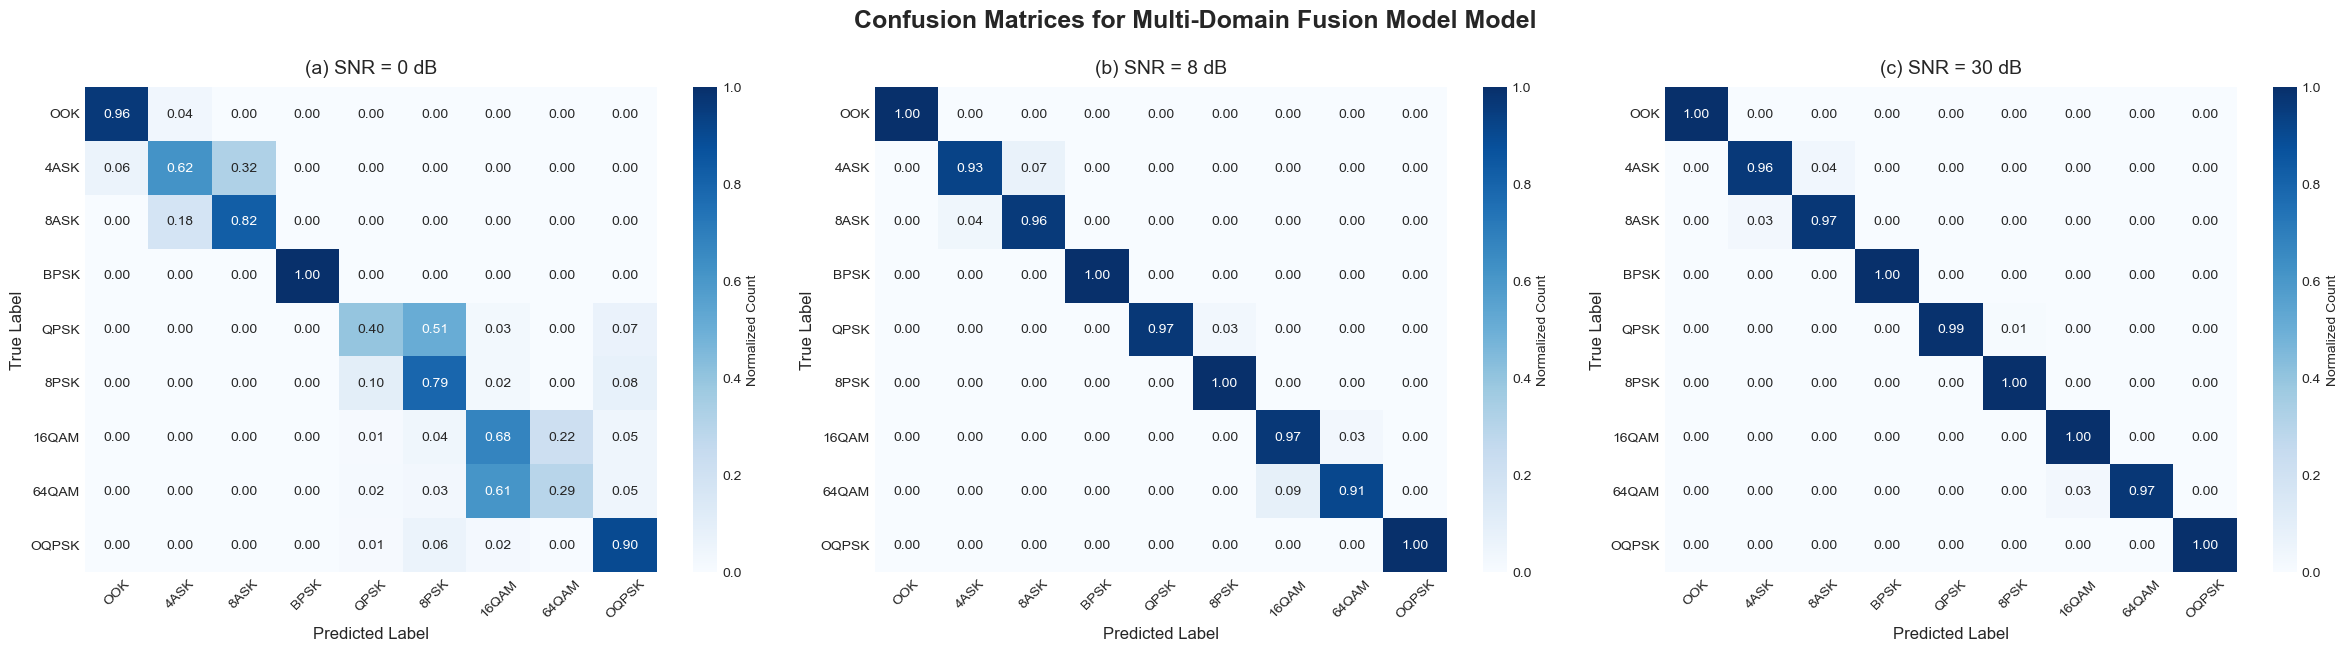

In [ ]:
# --- USAGE EXAMPLE ---
plot_confusion_matrices_for_snrs(
    model=model_new,
    model_name="Multi-Domain Fusion Model",
    dataloader=test_loader,
    device=device,
    target_modulations=TARGET_MODULATIONS,
    snrs_to_plot=[0,8,30],  # Example SNR values
    save_pdf=True,
    output_dir="result_MDF_NET",
    dpi=600
)